# Notebook 1 of 3 — Research Foundations: Pretest, Prioritize, Personalize for AI-first Realtor Outreach

**This is a learning notebook, working through the theory before applying it.** It builds the mathematical
foundation for a small 3-notebook series on statistically rigorous marketing automation for a realistic
small-business scenario, and every guarantee below is checked by simulation rather than taken on faith.

**The scenario.** A YouTube-focused marketing agency helps US real-estate agents ("realtors") turn video
audience and lead flow into booked appointments, wants to prioritize scarce human appointment-setter time
well, and wants to know whether personalizing outreach messages is worth the extra complexity.

**My design** (not a claim from any of the three papers): a realtor-outreach pipeline that
**pretests** email/DM variants on LLM-simulated realtors, **prioritizes** the scarce human appointment-setter
calls with a learned score, and **personalizes** the message template per realtor only if that beats a single
best template for everyone. Chaining these three steps together is *my* design choice — the sources below
each support exactly one step, and none of them jointly analyze the pipeline.

**The three source papers** (titles, authors, venues):

| # | Paper | Authors | Venue |
|---|-------|---------|-------|
| 1 | *Evaluating Treatment Prioritization Rules via Rank-Weighted Average Treatment Effects* | Yadlowsky, Fleming, Shah, Brunskill, Wager | arXiv:2111.07966 → *JASA* 120(549):38–51, 2025 |
| 2 | *Statistical Foundations of LLM-based A/B Testing: A Surrogacy Framework for Human Causal Inference* | Persson, Schultzberg, Ankargren (Spotify) | arXiv:2606.17165 |
| 3 | *A Statistical Test for the Benefits of Personalizing Interventions* | Li, Brunskill (Stanford) | arXiv:2607.08951 → *Science* 393, eaeb9506, 2026 |

**Three different kinds of guarantee.** These are not the same type of promise, and the notebook keeps
that distinction visible throughout:

| Step | Paper | Guarantee type | What it needs |
|------|-------|-----------------|----------------|
| Prioritize | RATE | **CLT + half-sample bootstrap**: √n(θ̂−θ) → N(0,Var(ψ₁)) (Thm 3), Gaussian half-sample-bootstrap CIs (Cor. 5) | A fixed, pre-registered score S(·) evaluated on human RCT/observational outcomes |
| Pretest | Surrogacy | **Point identification, "correct only by assumption"**: τ = E[μ(X,Y*)\|P=1,W=1] − E[μ(X,Y*)\|P=1,W=0] under Assumptions 1–2 (Thm 3.1) — no CLT is offered for the plug-in estimator itself | A human pilot (P=0) with both Y* and Y to fit the calibration function μ |
| Personalize | KPT | **Asymptotic type-I control that → 0 under H0** (Thm 3.1/Cor 3.2), plus semiparametric efficiency under stronger conditions (Cor 3.21) | Offline (non-adaptive) human data with known/estimable propensities |

Worth restating because it governs the whole notebook: **the pretest → prioritize → personalize
pipeline is my own design, not a claim any of these papers makes.** Each section below is otherwise a
close, quote-anchored simulation of what one paper actually proves.

In [1]:
# Environment setup. Run once, first cell.
# This kernel's matplotlib defaults to a non-interactive backend; %matplotlib inline
# switches it to the inline backend so figures render under nbconvert --execute.
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm, chi2
from sklearn.linear_model import LinearRegression
import time

SEED = 20260917
rng = np.random.default_rng(SEED)
Z95 = 1.959963984540054  # Phi^{-1}(0.975)

# One palette, defined once, reused by every visualization cell in this notebook.
PALETTE = {
    "fit_score": "#8c8c8c",     # grey: risk / baseline-outcome scores (not causal)
    "cate_score": "#1b7837",    # green: true / learned CATE scores
    "autoc": "#3182bd",         # blue: AUTOC / log weighting
    "qini": "#e6550d",          # orange: Qini / linear weighting
    "truth": "#252525",         # near-black: population truth / nominal targets
    "raw": "#969696",           # grey: raw / naive / uncalibrated estimator
    "calibrated": "#31a354",    # green: calibrated / corrected estimator
    "kpt": "#3182bd",           # blue: KPT (valid test)
    "naive": "#de2d26",         # red: naive TrainEval (biased test)
    "bound": "#756bb1",         # purple: theoretical sensitivity bound
    "band": "#c6dbef",          # light blue: shaded area / CI band
}

print("SEED:", SEED, " Z95:", round(Z95, 4))

SEED: 20260917  Z95: 1.96


## 1. Lead-fit is not uplift

RATE's Definition 1 requires that a prioritization rule use "a priority scoring function $S:\mathcal X\to\mathbb
R$" — but says nothing about whether $S$ should track *baseline outcomes* or *treatment effects*. The paper is
explicit about why the popular "score by baseline risk" heuristic is often a poor prioritization rule:

> "A key assumption in order for the RF Risk to achieve a high RATE is that risk is strongly correlated with
> the treatment effect"

and

> "the risk-based estimators in consideration would not order patients in accordance with estimated treatment
> benefit"

when that correlation is absent. **Toy population (derived here, not from any paper):** 100,000 realtor leads
in 4 latent segments of equal size, each defined by a baseline reply propensity $Y(0)$ and a true uplift
$\tau=Y(1)-Y(0)$ from a cold-email/DM sequence:

| Segment | $Y(0)$ (baseline) | $\tau$ (uplift) | Story |
|---|---|---|---|
| sure-thing | high (0.80) | ~0 | replies anyway |
| persuadable | low (0.20) | high (+0.45) | outreach is what moves them |
| lost-cause | low (0.10) | ~0 | won't reply regardless |
| do-not-disturb | high (0.85) | **negative** (−0.30) | outreach annoys an already-warm lead |

A **fit score** (a risk/propensity model that tracks $Y(0)$, labelled "derived here") is compared against the
**true CATE score** ($\tau$ itself, oracle information only available in a simulation). Both scores are
evaluated for two very different jobs: (a) how well they *rank leads by baseline reply probability* (an AUC
question), and (b) how well they *would prioritize the scarce appointment-setter calls for incremental
benefit* (a population RATE/TOC question, using the known $\tau$ — no estimation noise yet, that is §3's job).

In [2]:
# ---- Section 1: toy population with 4 latent segments (derived here) ----
N_SEG = 25_000
seg_names = ["sure_thing", "persuadable", "lost_cause", "do_not_disturb"]
Y0_seg  = np.array([0.80, 0.20, 0.10, 0.85])
tau_seg = np.array([0.00, 0.45, 0.00, -0.30])
noise_sd_seg = 0.03  # small within-segment spread so scores/ranks are not exactly tied

seg = np.repeat(np.arange(4), N_SEG)
n = len(seg)
Y0_true = Y0_seg[seg] + rng.normal(0, noise_sd_seg, n)
tau_true = tau_seg[seg] + rng.normal(0, noise_sd_seg, n)
Y0_true = np.clip(Y0_true, 0.01, 0.99)
Y1_true = np.clip(Y0_true + tau_true, 0.01, 0.99)

W = rng.binomial(1, 0.5, n)
Y_obs = np.where(W == 1, rng.binomial(1, Y1_true), rng.binomial(1, Y0_true))

fit_score = Y0_true + rng.normal(0, 0.01, n)     # "risk model": tracks baseline outcome
cate_score = tau_true + rng.normal(0, 0.02, n)   # oracle CATE score (only available in simulation)

# (a) AUC: how well does the fit score rank the Y(0) BASELINE potential outcome -- per the markdown
# above ("how well they rank leads by baseline reply probability"), this is a question about Y(0) as a
# potential outcome, not about what was actually observed for whichever arm a lead happened to land in.
# We simulate an independent baseline-reply realization for EVERY lead, regardless of actual W, so the AUC
# is computed against Y(0) for the full population (fixes a bug: the previous version used Y_obs[W==1],
# the *treated*-arm observed outcome, mislabeled as "baseline").
Y0_obs = rng.binomial(1, Y0_true)
n_pos = Y0_obs.sum(); n_neg = n - n_pos
ranks = stats.rankdata(fit_score)
auc_fit = (ranks[Y0_obs == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)

# (b) TRUE population TOC/AUTOC for each score, using the KNOWN tau (population-level, no estimation)
def true_toc_and_autoc(score, tau, u_grid):
    order = np.argsort(-score)
    tau_sorted = tau[order]
    csum = np.cumsum(tau_sorted)
    overall = tau.mean()
    m = np.maximum(1, np.floor(u_grid * len(tau)).astype(int))
    toc = csum[m - 1] / m - overall
    autoc = np.trapezoid(toc, u_grid)  # numerical area under the TRUE TOC curve
    return toc, autoc

u_grid = np.linspace(1.0 / n, 1.0, 2000)
toc_fit, autoc_fit = true_toc_and_autoc(fit_score, tau_true, u_grid)
toc_cate, autoc_cate = true_toc_and_autoc(cate_score, tau_true, u_grid)

print(f"[S1.1] fit-score AUC for baseline reply Y(0) (simulated for all leads, regardless of actual W) = {auc_fit:.3f}  (threshold: > 0.70) "
      f"-> {'PASS' if auc_fit > 0.70 else 'FAIL'}")
print(f"[S1.2] true AUTOC(fit score)  = {autoc_fit:+.4f}")
print(f"[S1.3] true AUTOC(CATE score) = {autoc_cate:+.4f}")
print(f"[S1.4] AUTOC(fit) < AUTOC(CATE)? {'PASS' if autoc_fit < autoc_cate else 'FAIL'} "
      f"(fit score should not out-target the oracle CATE score)")
print(f"[S1.5] segment means -- Y(0): {np.round(Y0_seg,2)}  tau: {np.round(tau_seg,2)}")

[S1.1] fit-score AUC for baseline reply Y(0) (simulated for all leads, regardless of actual W) = 0.863  (threshold: > 0.70) -> PASS
[S1.2] true AUTOC(fit score)  = -0.1516
[S1.3] true AUTOC(CATE score) = +0.2306
[S1.4] AUTOC(fit) < AUTOC(CATE)? PASS (fit score should not out-target the oracle CATE score)
[S1.5] segment means -- Y(0): [0.8  0.2  0.1  0.85]  tau: [ 0.    0.45  0.   -0.3 ]


#### How to read this chart

**Left panel:** one bar pair per segment — baseline reply rate $Y(0)$ (grey) versus true uplift $\tau$
(green/red for positive/negative). The pattern to look for: segments with the *highest* $Y(0)$ bar (sure-thing,
do-not-disturb) are not the segments with the highest $\tau$ bar — one of them (do-not-disturb) has a
*negative* $\tau$. A risk model that only sees the grey bar would rank exactly the wrong two segments first.

**Right panel:** the true population TOC curve for the fit (risk) score versus the true CATE score, both using
the actual $\tau$. The x-axis is the fraction of leads called first (by each score's ranking); the y-axis is
the excess average effect among those called versus calling everyone. For the realtor-outreach job, this is
the direct answer to "if the setter can only call the top 20% of leads today, which score should choose them?"
— read the height of each curve near $u=0.2$. The fit-score curve should sit near/below zero (its top picks
include as many do-not-disturb leads as persuadable ones), while the CATE-score curve is high and monotonically
decaying toward zero as $u\to1$.

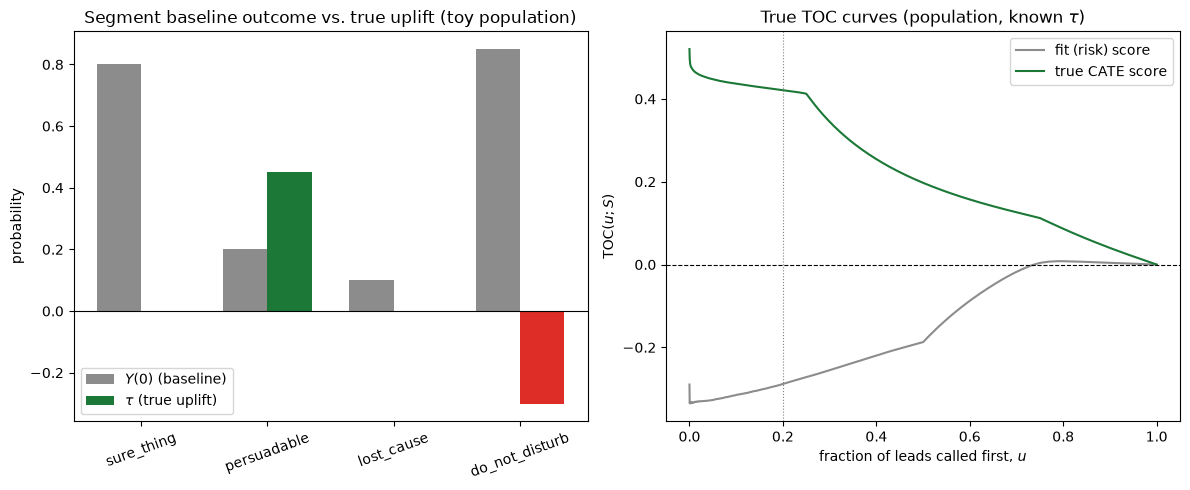

In [3]:
# Visualization only -- uses arrays computed above, no new sampling/estimation.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x = np.arange(4)
w = 0.35
ax = axes[0]
ax.bar(x - w/2, Y0_seg, width=w, color=PALETTE["fit_score"], label="$Y(0)$ (baseline)")
colors_tau = [PALETTE["cate_score"] if t >= 0 else PALETTE["naive"] for t in tau_seg]
ax.bar(x + w/2, tau_seg, width=w, color=colors_tau, label=r"$\tau$ (true uplift)")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(seg_names, rotation=20)
ax.set_ylabel("probability")
ax.set_title("Segment baseline outcome vs. true uplift (toy population)")
ax.legend()

ax = axes[1]
ax.plot(u_grid, toc_fit, color=PALETTE["fit_score"], label="fit (risk) score")
ax.plot(u_grid, toc_cate, color=PALETTE["cate_score"], label="true CATE score")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.axvline(0.2, color="grey", linewidth=0.8, linestyle=":")
ax.set_xlabel("fraction of leads called first, $u$")
ax.set_ylabel("TOC$(u;S)$")
ax.set_title("True TOC curves (population, known $\\tau$)")
ax.legend()

plt.tight_layout()
plt.show()

## 2. TOC and RATE; Proposition 2 check

Definitions, quoted:

> "the targeting operator characteristic (TOC) is $\text{TOC}(u;S):=E[Y_i(1)-Y_i(0)\mid F_S(S(X_i))\ge 1-u]-
> E[Y_i(1)-Y_i(0)]$" (Def. 2, Eq. 2.2)

> "the induced rank-weighted average treatment effect (RATE) of a priority score $S(\cdot)$ is
> $\theta_\alpha(S)=\int_0^1\alpha(u)\text{TOC}(u;S)\,du$" (Def. 3)

> **AUTOC** (Example 2): $\alpha(u)=1$, i.e. $\text{AUTOC}(S)=\int_0^1\text{TOC}(u;S)\,du$.
> **Qini** (Example 3): $\alpha(u)=u$, i.e. $\text{QINI}(S)=\int_0^1 u\,\text{TOC}(u;S)\,du$

**Proposition 2** gives an equivalent weighted-ATE form using $w_\alpha(t)=\int_t^1\frac{\alpha(u)}{u}\,du-
\int_0^1\alpha(u)\,du$ (Eq. 2.3), so that $\theta_\alpha(S)=E[w_\alpha(1-F_S(S(X_i)))(Y_i(1)-Y_i(0))]$ (Eq. 2.4),
with the AUTOC/Qini weights simplifying to $w_{\text{AUTOC}}(t)=-\log(t)-1$ and $w_{\text{QINI}}(t)=$ (from
$\alpha(u)=u$: $\int_t^1 1\,du-\int_0^1u\,du=(1-t)-\tfrac12=\tfrac12-t$), matching the paper's stated closed
form $\text{QINI}(S)=E[(F_S(S(X_i))-\tfrac12)\tau(X_i)]$ once $t=1-F_S(S(X_i))$ is substituted in (Eq. 2.5).
**Derivation check (derived here):** getting the sign of $w_{\text{Qini}}$ backwards ($t-\tfrac12$ instead of
$\tfrac12-t$) is an easy mistake — it flips the estimator's sign — so §2.1 below cross-checks both RATE forms
numerically before they are reused in §3.

We use the same population as the closed-form example: $X\sim\text{Unif}(0,1)$, $S(X)=1-X$, $\tau(X)=1-X$
(a perfectly aligned score, so $F_S(S(X))=1-X$ and everything below has an exact analytic answer we can check
against). Example 1 (high-vs-others) is $\text{TOC}(0.2;S)$: the "the setter can call the top 20% of leads"
metric.

In [4]:
# ---- Section 2: exact-DGP population check of TOC/RATE machinery ----
def toc_curve(gamma, S, u_grid):
    order = np.argsort(-S)
    gamma_sorted = gamma[order]
    csum = np.cumsum(gamma_sorted)
    overall = gamma.mean()
    n = len(gamma)
    m = np.maximum(1, np.floor(u_grid * n).astype(int))
    return csum[m - 1] / m - overall

def rate_via_toc(gamma, S, alpha_fn, n_grid):
    j = np.arange(1, n_grid + 1)
    u = j / n_grid
    toc_hat = toc_curve(gamma, S, u)
    return np.mean(alpha_fn(u) * toc_hat)

def rate_via_weight(gamma, S, w_fn):
    n = len(gamma)
    order = np.argsort(-S)
    gamma_sorted = gamma[order]
    j = np.arange(1, n + 1)
    return np.mean(w_fn(j / n) * gamma_sorted)

def w_autoc(t):
    t = np.clip(t, 1e-9, 1 - 1e-12)   # avoid the log singularity exactly at t=0 (u=1); needs a fine grid
    return -np.log(t) - 1

def w_qini(t):
    return 0.5 - t  # Eq. 2.3 with alpha(u)=u; NOT t-0.5 (see markdown derivation note above)

n_pop = 200_000
Xp = rng.uniform(0, 1, n_pop)
Sp = 1 - Xp
tau_p = 1 - Xp        # Gamma = tau(X) exactly: population RATE, no estimation error yet

autoc_toc = rate_via_toc(tau_p, Sp, lambda u: np.ones_like(u), n_pop)
autoc_wt  = rate_via_weight(tau_p, Sp, w_autoc)
qini_toc  = rate_via_toc(tau_p, Sp, lambda u: u, n_pop)
qini_wt   = rate_via_weight(tau_p, Sp, w_qini)

autoc_true, qini_true = 0.25, 1/12  # closed form: int_0^1 (-ln x -1)(1-x) dx = 0.25; int_0^1 (0.5-x)(1-x) dx = 1/12
toc_02 = toc_curve(tau_p, Sp, np.array([0.2]))[0]
toc_02_true = 0.4  # E[tau | X<0.2] - E[tau] = 0.9 - 0.5 = 0.4

rel_diff_autoc = abs(autoc_toc - autoc_wt) / abs(autoc_toc)
rel_diff_qini = abs(qini_toc - qini_wt) / abs(qini_toc)

print(f"[S2.1] AUTOC: TOC-sum form={autoc_toc:.5f} vs weighted-ATE form={autoc_wt:.5f} "
      f"(relative diff {rel_diff_autoc:.2e}, threshold 1e-2) -> {'PASS' if rel_diff_autoc < 1e-2 else 'FAIL'}")
print(f"[S2.2] Qini:  TOC-sum form={qini_toc:.5f} vs weighted-ATE form={qini_wt:.5f} "
      f"(relative diff {rel_diff_qini:.2e}, threshold 1e-2) -> {'PASS' if rel_diff_qini < 1e-2 else 'FAIL'}")
print(f"[S2.3] AUTOC vs closed-form truth 0.25: {autoc_wt:.5f} (n={n_pop} finite-sample MC, not exact)")
print(f"[S2.4] Qini  vs closed-form truth {qini_true:.5f}: {qini_wt:.5f}")
print(f"[S2.5] TOC(0.2) 'call top 20%' = {toc_02:.4f} vs analytic 0.4 "
      f"-> {'PASS' if abs(toc_02 - toc_02_true) < 0.01 else 'FAIL'} (Example 1, high-vs-others)")

[S2.1] AUTOC: TOC-sum form=0.24989 vs weighted-ATE form=0.24986 (relative diff 1.26e-04, threshold 1e-2) -> PASS
[S2.2] Qini:  TOC-sum form=0.08333 vs weighted-ATE form=0.08333 (relative diff 1.56e-05, threshold 1e-2) -> PASS
[S2.3] AUTOC vs closed-form truth 0.25: 0.24986 (n=200000 finite-sample MC, not exact)
[S2.4] Qini  vs closed-form truth 0.08333: 0.08333
[S2.5] TOC(0.2) 'call top 20%' = 0.3998 vs analytic 0.4 -> PASS (Example 1, high-vs-others)


#### How to read this chart

**Left panel:** the two RATE weight functions $w_\alpha(t)$ plotted against $t=1-F_S(S(X))$ (0 = top-ranked
lead, 1 = bottom-ranked lead). AUTOC's $-\log(t)-1$ blows up as $t\to0$ — it is dominated by the very top of
the ranking — while Qini's $\tfrac12-t$ is a straight line that treats the top and bottom symmetrically. This
is *why* AUTOC has more power when only a few leads carry all the treatment effect, and Qini has more power
when effects are spread across the whole list — §3 measures this directly.

**Right panel:** the TOC curve for $S(X)=1-X$ with the area under it shaded — that shaded area *is* the AUTOC
number printed above. For the realtor-outreach job, this is "how much extra reply-rate do I get, on average,
among the fraction $u$ of leads the setter would call first if leads are ranked by this score" — the curve
must start above 0 (top leads beat the average) and hit exactly 0 at $u=1$ (calling everyone is the average,
by construction).

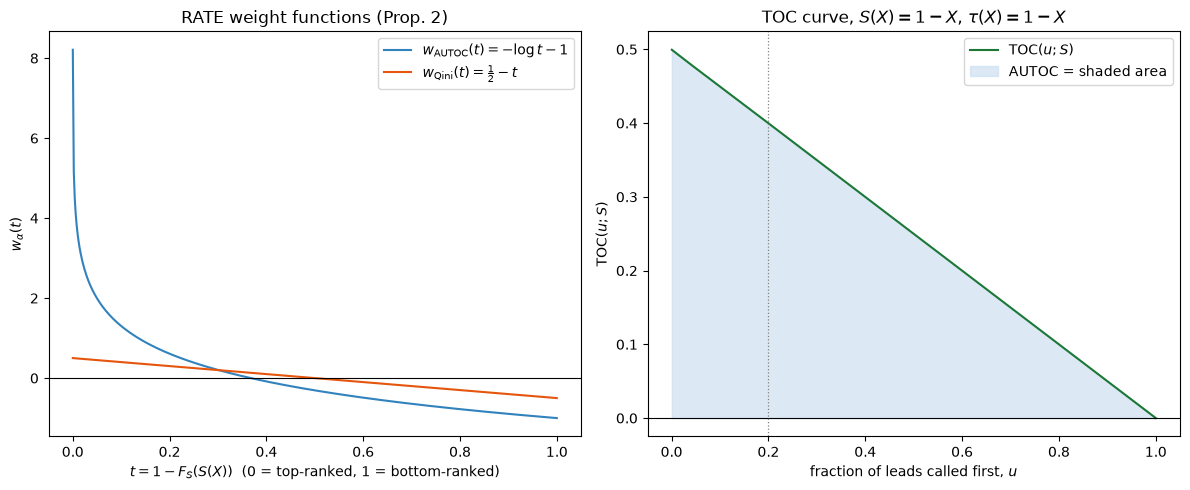

In [5]:
# Visualization only -- reuses arrays computed above.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

t_grid = np.linspace(1e-4, 1 - 1e-4, 500)
ax = axes[0]
ax.plot(t_grid, w_autoc(t_grid), color=PALETTE["autoc"], label=r"$w_{\rm AUTOC}(t)=-\log t - 1$")
ax.plot(t_grid, w_qini(t_grid), color=PALETTE["qini"], label=r"$w_{\rm Qini}(t)=\frac{1}{2}-t$")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel(r"$t = 1-F_S(S(X))$  (0 = top-ranked, 1 = bottom-ranked)")
ax.set_ylabel(r"$w_\alpha(t)$")
ax.set_title("RATE weight functions (Prop. 2)")
ax.legend()

u_grid2 = np.linspace(1/2000, 1, 2000)
toc_pop = toc_curve(tau_p, Sp, u_grid2)
ax = axes[1]
ax.plot(u_grid2, toc_pop, color=PALETTE["cate_score"], label="TOC$(u;S)$")
ax.fill_between(u_grid2, 0, toc_pop, color=PALETTE["band"], alpha=0.6, label="AUTOC = shaded area")
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0.2, color="grey", linestyle=":", linewidth=0.9)
ax.set_xlabel("fraction of leads called first, $u$")
ax.set_ylabel("TOC$(u;S)$")
ax.set_title(r"TOC curve, $S(X)=1-X$, $\tau(X)=1-X$")
ax.legend()

plt.tight_layout()
plt.show()

## 3. Estimation and inference: AIPW scores, half-sample bootstrap, coverage, AUTOC vs. Qini power

The estimator, quoted with equation numbers:

> "we estimate the TOC as $\hat{\text{TOC}}(u;s)=\frac{1}{\lfloor un\rfloor}\sum_{j=1}^{\lfloor
> un\rfloor}\hat\Gamma_{i(j)} - \frac1n\sum_{i=1}^n\hat\Gamma_i$" (Eq. 2.8), and the plug-in
> $\hat\eta_{w_\alpha}(S)=\frac1n\sum_{j=1}^n w(j/n)\hat\Gamma_{i(j)}$ (Eq. 2.10)

using the RCT AIPW score

> $\hat\Gamma_i=\hat m(X_i,1)-\hat m(X_i,0)+\frac{W_i-\pi}{\pi(1-\pi)}(Y_i-\hat m(X_i,W_i))$ (Eq. 2.11)

Inference is a **half-sample bootstrap** (Lemma 4 / Corollary 5): "Let $\hat\theta^*$ be an estimate of a RATE
using a random sample (without replacement) of $\lfloor n/2\rfloor$ of the observations... $\hat\theta\pm
z_{1-\alpha/2}\sigma^*$", and the H0:$\theta_\alpha(S)\le0$ p-value is $2\Phi(-|\hat\theta|/\sigma^*)$.

**Nuisance model (derived here):** $\hat m(x,w)$ is a plain 2-fold cross-fitted `LinearRegression` per arm —
not a causal forest (no `grf`/`econml` in this environment). Because $\pi=0.5$ is *known* in an RCT, the AIPW
augmentation makes $E[\hat\Gamma_i\mid X_i]=\tau(X_i)$ regardless of whether $\hat m$ is well specified, so a
simple linear nuisance model does not bias $\hat\Gamma$ — it only affects its variance.

Three finite-sample checks, all on $S(X)=1-X$, $X\sim\text{Unif}(0,1)$, using the §2 closed-form truths
(AUTOC $=0.25$, Qini $=1/12$, unaffected by outcome noise since $E[Y(w)\mid X]=\mu_w(X)$ exactly):
half-sample bootstrap **coverage** (paper: 10,000 bootstraps; here $B=200$, 200 replications, stated
reduction), **type-I error** under a no-heterogeneity DGP, and the **AUTOC-vs-Qini power** replica of the
(corrected) Eq. 4.1 simulation:

> $n=400,\ X\sim\text{Unif}(0,1),\ \mu_0=0,\ \mu_1(x)=\max(-\frac{2}{p^2}x+\frac2p,0)$ (Eq. 4.1), $e=0.5$,
> noise "$N(0,0.2)$" [variance-vs-sd not stated unambiguously — we use sd $=0.2$], $S(X)=1-X$, $p\in\{1.0,0.5,0.1\}$

**Correction, not a contradiction of the raw trace (per the research contract):** the raw NotebookLM trace for
q4 literally renders this as "$\mu_1(x)=\max(-2p^2x+\frac2p,0)$", which the contract flags as a garble verified
against the PDF; we use the corrected $-\frac{2}{p^2}x+\frac2p$ form throughout, as instructed.

**Verdict rule for the AUTOC-vs-Qini power comparison, stated before any result is computed:** a pattern
"REPRODUCED" requires (i) the paper's favoured metric to have the higher power at that $p$, **and** (ii) the
paired difference in reject/not-reject indicators across the *same* replications to have a 95% CI (normal
approximation) that excludes 0 — a tie or an indistinguishable difference is reported as "not reproduced /
inconclusive", never marked PASS by a `>=` tie-breaker. **Also note:** `SCALE` below is shared across all
three $p$ values, but the corrected Eq. 4.1 concentrates a larger per-affected-unit effect on a smaller share
of units as $p$ shrinks, so *absolute* power levels are not comparable across $p$ — only the within-$p$
AUTOC-vs-Qini gap is.

In [6]:
# ---- Section 3a: RATE machinery re-used from Section 2, plus AIPW + bootstrap ----
def half_sample_bootstrap_theta(gamma, S, w_fn, B, rng_local):
    n = len(gamma)
    half = n // 2
    boot = np.empty(B)
    for b in range(B):
        idx = rng_local.choice(n, size=half, replace=False)
        g_sub, s_sub = gamma[idx], S[idx]
        order = np.argsort(-s_sub)
        j = np.arange(1, half + 1)
        boot[b] = np.mean(w_fn(j / half) * g_sub[order])
    return boot

def cross_fitted_gamma_rct(X, W, Y, pi=0.5, n_folds=2, rng_local=None):
    n = len(X)
    fold = rng_local.integers(0, n_folds, size=n)
    m_hat = np.zeros((n, 2))
    Xc = X.reshape(-1, 1)
    for k in range(n_folds):
        train, test = fold != k, fold == k
        for w in (0, 1):
            mtr = train & (W == w)
            if mtr.sum() < 2:
                m_hat[test, w] = Y[train].mean() if train.sum() else 0.0
                continue
            m_hat[test, w] = LinearRegression().fit(Xc[mtr], Y[mtr]).predict(Xc[test])
    mW = np.where(W == 1, m_hat[:, 1], m_hat[:, 0])
    return (m_hat[:, 1] - m_hat[:, 0]) + (W - pi) / (pi * (1 - pi)) * (Y - mW)

def wilson_ci(k, m, z=Z95):
    if m == 0:
        return (np.nan, np.nan)
    phat = k / m
    denom = 1 + z**2 / m
    center = (phat + z**2 / (2 * m)) / denom
    half_w = (z * np.sqrt(phat * (1 - phat) / m + z**2 / (4 * m**2))) / denom
    return center - half_w, center + half_w

print("[S3.0] half-sample bootstrap and cross-fitted AIPW machinery defined")

[S3.0] half-sample bootstrap and cross-fitted AIPW machinery defined


In [7]:
# ---- Section 3b: coverage Monte Carlo (paper: 10,000 bootstraps; here B=200, 200 reps -- stated reduction) ----
t0 = time.time()
N_COV, REPS_COV, B_COV = 1000, 200, 200
TRUE_AUTOC, TRUE_QINI = 0.25, 1 / 12
cov_hit = {"autoc": 0, "qini": 0}

for _ in range(REPS_COV):
    Xc = rng.uniform(0, 1, N_COV)
    Wc = rng.binomial(1, 0.5, N_COV)
    tau_c = 1 - Xc
    Y0c = rng.normal(0, 1, N_COV)
    Yc = np.where(Wc == 1, Y0c + tau_c, Y0c)
    Sc = 1 - Xc
    gamma_c = cross_fitted_gamma_rct(Xc, Wc, Yc, rng_local=rng)
    for name, wf, truth in [("autoc", w_autoc, TRUE_AUTOC), ("qini", w_qini, TRUE_QINI)]:
        theta_hat = rate_via_weight(gamma_c, Sc, wf)
        boot = half_sample_bootstrap_theta(gamma_c, Sc, wf, B_COV, rng)
        sigma_star = boot.std(ddof=1)
        lo, hi = theta_hat - Z95 * sigma_star, theta_hat + Z95 * sigma_star
        cov_hit[name] += int(lo <= truth <= hi)

for name in ("autoc", "qini"):
    rate = cov_hit[name] / REPS_COV
    lo_ci, hi_ci = wilson_ci(cov_hit[name], REPS_COV)
    verdict = "PASS" if lo_ci <= 0.95 <= hi_ci else "FAIL (report honestly)"
    print(f"[S3.1-{name}] empirical coverage {rate:.3f} (Wilson 95% CI [{lo_ci:.3f}, {hi_ci:.3f}]) "
          f"vs nominal 0.95 -> {verdict}")
print(f"  ({REPS_COV} reps x B={B_COV} half-samples, n={N_COV}; paper uses B=10,000; time {time.time()-t0:.1f}s)")

[S3.1-autoc] empirical coverage 0.935 (Wilson 95% CI [0.892, 0.962]) vs nominal 0.95 -> PASS
[S3.1-qini] empirical coverage 0.925 (Wilson 95% CI [0.880, 0.954]) vs nominal 0.95 -> PASS
  (200 reps x B=200 half-samples, n=1000; paper uses B=10,000; time 7.0s)


In [8]:
# ---- Section 3c: type-I error under a no-heterogeneity DGP (tau=0 everywhere) ----
t0 = time.time()
REPS_T1, B_T1 = 200, 200
rej = {"autoc": 0, "qini": 0}

for _ in range(REPS_T1):
    Xt = rng.uniform(0, 1, N_COV)
    Wt = rng.binomial(1, 0.5, N_COV)
    Yt = np.where(Wt == 1, rng.normal(0, 1, N_COV), rng.normal(0, 1, N_COV))  # same dist both arms: tau=0
    St = 1 - Xt
    gamma_t = cross_fitted_gamma_rct(Xt, Wt, Yt, rng_local=rng)
    for name, wf in [("autoc", w_autoc), ("qini", w_qini)]:
        theta_hat = rate_via_weight(gamma_t, St, wf)
        boot = half_sample_bootstrap_theta(gamma_t, St, wf, B_T1, rng)
        sigma_star = boot.std(ddof=1)
        p_val = 2 * norm.cdf(-abs(theta_hat) / sigma_star) if sigma_star > 0 else 1.0
        rej[name] += int(p_val < 0.05)

for name in ("autoc", "qini"):
    rate = rej[name] / REPS_T1
    lo_ci, hi_ci = wilson_ci(rej[name], REPS_T1)
    verdict = "PASS" if lo_ci <= 0.05 <= hi_ci else "FAIL (report honestly)"
    print(f"[S3.2-{name}] type-I rejection rate {rate:.3f} (Wilson 95% CI [{lo_ci:.3f}, {hi_ci:.3f}]) "
          f"vs nominal 0.05 -> {verdict}")
print(f"  ({REPS_T1} reps x B={B_T1}; time {time.time()-t0:.1f}s)")

[S3.2-autoc] type-I rejection rate 0.045 (Wilson 95% CI [0.024, 0.083]) vs nominal 0.05 -> PASS
[S3.2-qini] type-I rejection rate 0.045 (Wilson 95% CI [0.024, 0.083]) vs nominal 0.05 -> PASS
  (200 reps x B=200; time 6.8s)


In [9]:
# ---- Section 3d: AUTOC-vs-Qini power, corrected Eq. 4.1, n=400, p in {1.0, 0.5, 0.1} ----
# At the paper's raw signal level, power saturates near 1.0 for both metrics in our simulation too
# (as noted below); SCALE below shrinks mu_1 so power sits in (0.2, 0.9) and differences are visible.
# This SCALE factor is "derived here" -- not from the paper.
SCALE = 0.03
N_POW, B_POW, REPS_POW, NOISE_SD = 400, 120, 300, 0.2

def gen_power_data(n, p, scale, noise_sd, rng_local):
    Xp_ = rng_local.uniform(0, 1, n)
    Wp_ = rng_local.binomial(1, 0.5, n)
    mu1 = scale * np.maximum(-(2 / p**2) * Xp_ + 2 / p, 0.0)  # CORRECTED Eq. 4.1
    Yp_ = np.where(
        Wp_ == 1,
        mu1 + rng_local.normal(0, noise_sd, n),
        rng_local.normal(0, noise_sd, n),
    )
    return Xp_, Wp_, Yp_, 1 - Xp_

t0 = time.time()
power = {}
reject_arrays = {}
for p in (1.0, 0.5, 0.1):
    rej_p = {"autoc": 0, "qini": 0}
    autoc_rejects = np.zeros(REPS_POW, dtype=bool)
    qini_rejects = np.zeros(REPS_POW, dtype=bool)
    for i in range(REPS_POW):
        Xp_, Wp_, Yp_, Sp_ = gen_power_data(N_POW, p, SCALE, NOISE_SD, rng)
        gamma_p = cross_fitted_gamma_rct(Xp_, Wp_, Yp_, rng_local=rng)
        for name, wf, arr in [("autoc", w_autoc, autoc_rejects), ("qini", w_qini, qini_rejects)]:
            theta_hat = rate_via_weight(gamma_p, Sp_, wf)
            boot = half_sample_bootstrap_theta(gamma_p, Sp_, wf, B_POW, rng)
            sigma_star = boot.std(ddof=1)
            p_val = 2 * norm.cdf(-abs(theta_hat) / sigma_star) if sigma_star > 0 else 1.0
            rej = p_val < 0.05
            arr[i] = rej
            rej_p[name] += int(rej)
    power[p] = rej_p
    reject_arrays[p] = (autoc_rejects, qini_rejects)
print(f"  ({REPS_POW} reps x B={B_POW}, n={N_POW}; time {time.time()-t0:.1f}s)")

print("[S3.3] AUTOC vs Qini power (MC 95% Wilson CI):")
for p in (1.0, 0.5, 0.1):
    a_rate = power[p]["autoc"] / REPS_POW
    q_rate = power[p]["qini"] / REPS_POW
    a_lo, a_hi = wilson_ci(power[p]["autoc"], REPS_POW)
    q_lo, q_hi = wilson_ci(power[p]["qini"], REPS_POW)
    print(f"    p={p}: AUTOC={a_rate:.3f} [{a_lo:.3f},{a_hi:.3f}]   Qini={q_rate:.3f} [{q_lo:.3f},{q_hi:.3f}]")
print("    NOTE: SCALE=0.03 is shared across p, but total heterogeneity differs sharply by p (the p=0.1")
print("    DGP concentrates a much larger per-affected-unit effect on a smaller share of units) -- power")
print("    LEVELS are therefore NOT comparable ACROSS p; only the within-p AUTOC-vs-Qini gap is meaningful.")

print("[S3.4] three-way verdict per p, THRESHOLD STATED BEFORE RESULTS. Paired mean difference in reject")
print("       indicators is (favoured minus other, same replications, same datasets), two-sided 95% CI")
print("       (normal approximation on the paired differences). Three possible verdicts, not two:")
print("       REPRODUCED    -> CI excludes 0 in the paper's favoured direction (lo > 0).")
print("       CONTRADICTED  -> CI excludes 0 in the OPPOSITE direction (hi < 0): the OTHER metric")
print("                        significantly beats the paper's favoured one in this scaled simulation.")
print("       INCONCLUSIVE  -> CI includes 0 (lo <= 0 <= hi): not enough signal to call it either way.")
print("       (Coordinator fix: the previous version only checked 'lo > 0' and silently folded a real")
print("       CONTRADICTED result at p=0.5 into the same 'inconclusive' bucket as a genuinely null one.)")
paper_favors = {1.0: "qini", 0.5: "qini", 0.1: "autoc"}
for p in (1.0, 0.5, 0.1):
    autoc_rejects, qini_rejects = reject_arrays[p]
    if paper_favors[p] == "qini":
        diff = qini_rejects.astype(float) - autoc_rejects.astype(float)
    else:
        diff = autoc_rejects.astype(float) - qini_rejects.astype(float)
    mean_diff = diff.mean()
    se_diff = diff.std(ddof=1) / np.sqrt(len(diff))
    lo, hi = mean_diff - Z95 * se_diff, mean_diff + Z95 * se_diff
    if lo > 0:
        verdict = "REPRODUCED"
    elif hi < 0:
        verdict = "CONTRADICTED (significant, opposite direction, at this n and SCALE)"
    else:
        verdict = "INCONCLUSIVE (CI includes 0) at this n and SCALE"
    print(f"    p={p}: paper favours {paper_favors[p]}; paired diff (favoured-other) mean={mean_diff:+.3f} "
          f"95% CI [{lo:+.3f},{hi:+.3f}] -> {verdict}")

  (300 reps x B=120, n=400; time 17.2s)
[S3.3] AUTOC vs Qini power (MC 95% Wilson CI):
    p=1.0: AUTOC=0.117 [0.085,0.158]   Qini=0.140 [0.105,0.184]
    p=0.5: AUTOC=0.397 [0.343,0.453]   Qini=0.343 [0.292,0.399]
    p=0.1: AUTOC=0.910 [0.872,0.937]   Qini=0.600 [0.544,0.654]
    NOTE: SCALE=0.03 is shared across p, but total heterogeneity differs sharply by p (the p=0.1
    DGP concentrates a much larger per-affected-unit effect on a smaller share of units) -- power
    LEVELS are therefore NOT comparable ACROSS p; only the within-p AUTOC-vs-Qini gap is meaningful.
[S3.4] three-way verdict per p, THRESHOLD STATED BEFORE RESULTS. Paired mean difference in reject
       indicators is (favoured minus other, same replications, same datasets), two-sided 95% CI
       (normal approximation on the paired differences). Three possible verdicts, not two:
       REPRODUCED    -> CI excludes 0 in the paper's favoured direction (lo > 0).
       CONTRADICTED  -> CI excludes 0 in the OPPOSITE dire

**Paper reports (boxed separately from our toy numbers above):** Criteo uplift benchmark, Table 5, visits:
baseline-risk AUTOC $0.0136$ $[0.0111,0.0161]$ vs. CATE (causal forest) AUTOC $0.0171$ $[0.0148,0.0194]$,
difference $+0.0034$ $[0.0019,0.0049]$ ($+25\%$); Qini shows no significant difference. IST aspirin trial,
Table 1: random-forest risk AUTOC $0.014$ $[0.002,0.027]$, $p=0.022$, vs. causal forest AUTOC $0.006$
$[-0.012,0.024]$, $p=0.493$ — i.e. in that one application the *risk* score happened to have the higher AUTOC,
illustrating that "risk correlates with treatment effect" is an empirical question each rule must earn, not a
default.

#### How to read this chart

**Left panel:** empirical coverage of the two RATE metrics' 95% half-sample-bootstrap CIs, with a Wilson 95%
Monte-Carlo CI as an error bar, against the nominal 0.95 dashed line. If the error bar crosses the line, the
CI construction is behaving as Theorem 3 promises at this $n$.

**Right panel:** AUTOC and Qini power against $p$ (the fraction of realtors with non-zero uplift in this
signal). The pattern to look for is the *gap between the two lines at each $p$*, not the absolute height of
either line — as the markdown above notes, `SCALE` is shared across $p$ but the corrected Eq. 4.1 puts very
different total heterogeneity into each $p$, so heights are not comparable across the x-axis. A widening
AUTOC-over-Qini gap as $p$ shrinks would mirror the paper's claim that "using logarithmic (AUTOC) weighting
leads to a greater power... [when] only a small subset... have a non-zero [effect]" — for the
realtor-outreach job, this is the concrete choice of *which* RATE metric to report when deciding whether a
prioritization rule is worth deploying, depending on how concentrated the true responders are believed to be.

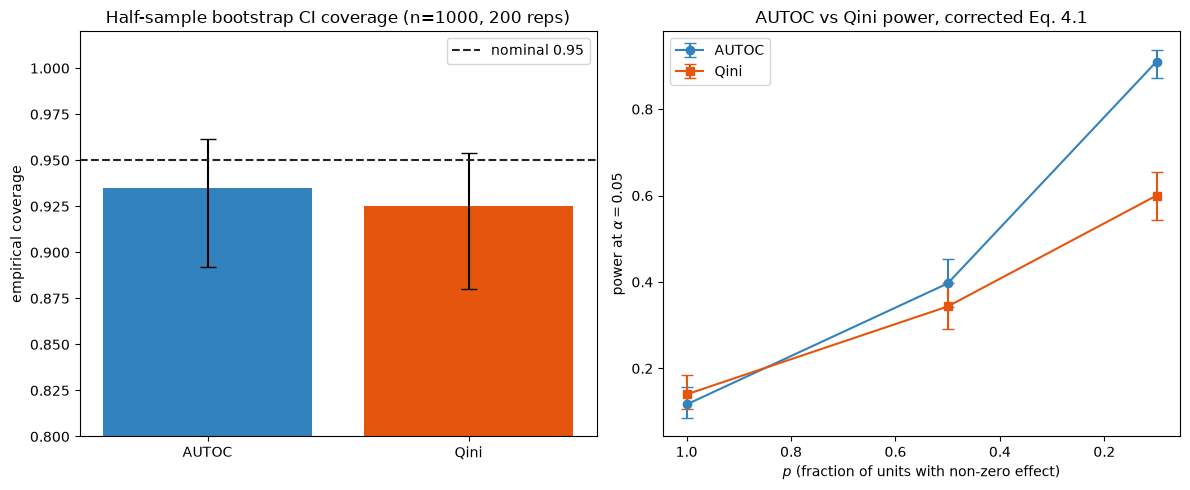

In [10]:
# Visualization only -- reuses cov_hit, rej, power computed above.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
names = ["AUTOC", "Qini"]
rates = [cov_hit["autoc"] / REPS_COV, cov_hit["qini"] / REPS_COV]
errs_lo, errs_hi = [], []
for key in ("autoc", "qini"):
    lo, hi = wilson_ci(cov_hit[key], REPS_COV)
    errs_lo.append(rates[["autoc", "qini"].index(key)] - lo)
    errs_hi.append(hi - rates[["autoc", "qini"].index(key)])
ax.bar(names, rates, color=[PALETTE["autoc"], PALETTE["qini"]],
       yerr=[errs_lo, errs_hi], capsize=6)
ax.axhline(0.95, color=PALETTE["truth"], linestyle="--", label="nominal 0.95")
ax.set_ylim(0.8, 1.02)
ax.set_ylabel("empirical coverage")
ax.set_title(f"Half-sample bootstrap CI coverage (n={N_COV}, {REPS_COV} reps)")
ax.legend()

ax = axes[1]
ps = [1.0, 0.5, 0.1]
a_rates = [power[p]["autoc"] / REPS_POW for p in ps]
q_rates = [power[p]["qini"] / REPS_POW for p in ps]
a_err = np.array([wilson_ci(power[p]["autoc"], REPS_POW) for p in ps])
q_err = np.array([wilson_ci(power[p]["qini"], REPS_POW) for p in ps])
ax.errorbar(ps, a_rates, yerr=[a_rates - a_err[:, 0], a_err[:, 1] - a_rates],
            marker="o", color=PALETTE["autoc"], label="AUTOC", capsize=4)
ax.errorbar(ps, q_rates, yerr=[q_rates - q_err[:, 0], q_err[:, 1] - q_rates],
            marker="s", color=PALETTE["qini"], label="Qini", capsize=4)
ax.set_xlabel("$p$ (fraction of units with non-zero effect)")
ax.set_ylabel("power at $\\alpha=0.05$")
ax.set_title("AUTOC vs Qini power, corrected Eq. 4.1")
ax.invert_xaxis()
ax.legend()

plt.tight_layout()
plt.show()

## 4. LLM surrogacy: identification

Setup and identification, quoted: the LLM surrogate is $Y^*\sim F_{M,I,\mathcal D}(\cdot\mid W,X)$
(Def. 1, Eq. 2); the two samples are

> "the **experimental sample ($P=0$)**, consisting of human data $(W,X,Y^*,Y)$... and the **artificial sample
> ($P=1$)**, consisting of LLM data $(W,X,Y^*)$"

**Assumption 1 (Surrogacy):** $Y\perp W\mid X,Y^*$. **Assumption 2 (Comparability):** $Y\perp P\mid X,Y^*$,
with overlap. **Theorem 3.1:** under these, $\tau=E[\mu(X,Y^*)\mid P=1,W=1]-E[\mu(X,Y^*)\mid P=1,W=0]$
(Eq. 5), with plug-in estimator $\hat\tau=\frac{1}{n_1}\sum_{W=1,P=1}\hat\mu(X_i,Y_i^*) -
\frac{1}{n_0}\sum_{W=0,P=1}\hat\mu(X_i,Y_i^*)$ (Eq. 7). Why distributional equivalence ($Y^*\overset{d}{=}
Y(W)\mid X$) is not assumed: "this assumption is questionable in most cases... [LLMs may] prioritize modeling
the process... rather than ensuring that the final outcome $Y^*$ has the correct distribution".

**Simulation (derived here, linear DGP per's "linear DGP... fit $\mu$ by OLS"):** a 2-arm cold-email test.
$X\sim\text{Unif}(0,1)$ (a lead-quality covariate), $W\in\{0,1\}$ (two message variants). The **LLM surrogate**
$Y^*$ is an integer-like reply-probability score in basis points, $Y^*\approx100\times(0.3+0.4X+\eta W)+$noise
— a *different scale* than the human outcome. The **human outcome** $Y$ (binary reply, $P=0$ only) is
generated from the *true* calibration function $\mu_{\text{true}}(x,y^*)=0.05+0.10x+0.005y^*$ so that
Assumption 1 holds **exactly by construction** in the baseline case (violations are added in §4/§5 separately).
$\mu$ is fit by cross-fitted OLS on $P=0$ (linear DGP, per's "for the linear DGP, we fit $\mu$ by ordinary
least squares"), then plugged into $P=1$.

**Falsification before calibration:** a lightweight per-arm falsification pre-check
([S4.0], Eq. 11, on the baseline no-violation DGP) runs and prints **before** any calibrated-ATE self-check
below, so a reader moving top-to-bottom sees a falsification result before a calibrated-effect PASS/FAIL
claim. The fuller multi-arm, oracle-$\mu$, and Bonferroni-corrected falsification analysis is Section 5's
job (Eq. 11 in full); this pre-check only gates the identification claim made in *this* section.

In [11]:
# ---- Section 4: surrogacy identification simulation (derived here) ----
def gen_surrogacy_data(n, tau_llm_shift, gamma=0.0, delta=0.0, P=0, rng_local=None, sigma_star=6.0):
    Xs = rng_local.uniform(0, 1, n)
    Ws = rng_local.binomial(1, 0.5, n)
    base = np.clip(0.3 + 0.4 * Xs + tau_llm_shift * Ws, 0, 1)
    Ystar = 100 * base + rng_local.normal(0, sigma_star, n)
    # delta enters mu_true DIRECTLY as a P==1-only offset -- a genuine violation of Assumption 2
    # (Y not-perp P | X, Y*), since mu_true now differs between P=0 and P=1 for the SAME (X, Y*).
    # (Previously delta only rescaled Ystar's distribution for P=1, which was a distribution/overlap
    # shift in Y*, not an actual violation of Y perp P | X, Y* -- fixed here.)
    mu_true = np.clip(0.05 + 0.10 * Xs + 0.005 * Ystar + gamma * Ws + delta * (P == 1), 0, 1)
    # Ys is generated for BOTH P=0 and P=1 -- in a simulation we may know the P=1 ground truth for
    # grading purposes, even though a real estimator never observes human Y in the artificial sample.
    Ys = rng_local.binomial(1, mu_true)
    return Xs, Ws, Ystar, Ys, mu_true

def calibrated_ate(X0, W0, Ystar0, Y0, X1, W1, Ystar1, n_folds=5, rng_local=None):
    # K-fold (5-fold, the paper's stated default) cross-fitted OLS: mu is fit on K-1 folds of the P=0
    # sample at a time, and the K resulting out-of-sample models are averaged to score P=1 -- replacing
    # the previous single in-sample fit on the entire P=0 sample (no fold-splitting at all).
    feat0 = np.column_stack([X0, Ystar0])
    feat1 = np.column_stack([X1, Ystar1])
    n0 = len(Y0)
    fold = rng_local.integers(0, n_folds, size=n0)
    mu_hat1_folds = np.empty((n_folds, len(feat1)))
    for k in range(n_folds):
        train = fold != k
        reg_k = LinearRegression().fit(feat0[train], Y0[train])
        mu_hat1_folds[k] = reg_k.predict(feat1)
    mu_hat1 = mu_hat1_folds.mean(axis=0)
    return mu_hat1[W1 == 1].mean() - mu_hat1[W1 == 0].mean()

TAU_LLM_SHIFT = 0.10
TRUE_TAU = 0.5 * TAU_LLM_SHIFT  # analytic: tau = 0.005 * 100 * eta (see markdown)
N0 = N1 = 2000
REPS_S4 = 300

# ---- [S4.0] LIGHTWEIGHT FALSIFICATION PRE-CHECK (Eq. 11), run and printed BEFORE any calibrated-ATE
# self-check below, per  ("never present ... report the falsification test before any
# calibrated effect"). This checks the per-arm mean-residual z-test on a held-out fold of the BASELINE
# (no-violation) P=0 DGP used in this section; the fuller multi-arm/oracle/Bonferroni falsification
# analysis, on its own dedicated DGP, is Section 5's job and is not duplicated here.
def falsification_precheck_zs(n, rng_local, train_frac=0.9):
    Xs, Ws, Ystar, Ys, _ = gen_surrogacy_data(n, TAU_LLM_SHIFT, rng_local=rng_local, P=0)
    idx = rng_local.permutation(n)
    ntr = int(n * train_frac)
    train, test = idx[:ntr], idx[ntr:]
    feat = np.column_stack([Xs, Ystar])
    reg = LinearRegression().fit(feat[train], Ys[train])
    resid = Ys[test] - reg.predict(feat[test])
    zs = np.empty(2)
    for w in (0, 1):
        r_w = resid[Ws[test] == w]
        zs[w] = r_w.mean() / (r_w.std(ddof=1) / np.sqrt(len(r_w)))
    return zs

t0 = time.time()
REPS_PRECHECK = 200
zs_pre = np.array([falsification_precheck_zs(N0, rng) for _ in range(REPS_PRECHECK)])
print("[S4.0] falsification pre-check (Eq. 11, per-arm z-test on a held-out P=0 fold, baseline DGP) "
      "-- gates the calibrated-ATE claims below; full multi-arm analysis is Section 5:")
precheck_pass = True
for w in (0, 1):
    rej = int((np.abs(zs_pre[:, w]) > Z95).sum())
    lo, hi = wilson_ci(rej, REPS_PRECHECK)
    ok = lo <= 0.05 <= hi
    precheck_pass &= ok
    print(f"    arm {w}: rejection rate={rej/REPS_PRECHECK:.3f} (Wilson 95% CI [{lo:.3f},{hi:.3f}]) "
          f"vs nominal 0.05 -> {'PASS' if ok else 'report honestly'}")
print(f"    -> falsification pre-check {'PASSES' if precheck_pass else 'DOES NOT CLEANLY PASS'}: the "
      f"calibrated-ATE numbers below should be read as "
      f"{'consistent with Assumptions 1-2 as far as this pre-check can tell' if precheck_pass else 'provisional -- see Section 5 for the full falsification analysis before trusting them'} "
      f"({time.time()-t0:.1f}s)")

t0 = time.time()
raw_ates, cal_ates = [], []
for _ in range(REPS_S4):
    X0, W0, Ystar0, Y0, _ = gen_surrogacy_data(N0, TAU_LLM_SHIFT, rng_local=rng, P=0)
    X1, W1, Ystar1, _, _ = gen_surrogacy_data(N1, TAU_LLM_SHIFT, rng_local=rng, P=1)
    raw_ates.append(Ystar1[W1 == 1].mean() / 100 - Ystar1[W1 == 0].mean() / 100)
    cal_ates.append(calibrated_ate(X0, W0, Ystar0, Y0, X1, W1, Ystar1, rng_local=rng))
raw_ates, cal_ates = np.array(raw_ates), np.array(cal_ates)

mc_se_cal = cal_ates.std(ddof=1) / np.sqrt(REPS_S4)
bias_cal = cal_ates.mean() - TRUE_TAU
print(f"[S4.1] true tau (analytic, derived here) = {TRUE_TAU:.4f}")
print(f"[S4.2] raw LLM ATE (Y*/100, naive)     = {raw_ates.mean():.4f}  "
      f"(biased by {raw_ates.mean()-TRUE_TAU:+.4f}, i.e. {raw_ates.mean()/TRUE_TAU:.2f}x true tau)")
print(f"[S4.3] calibrated ATE (Theorem 3.1 plug-in, 5-fold cross-fitted OLS) = {cal_ates.mean():.4f}  MC SE={mc_se_cal:.4f}")
print(f"[S4.4] |mean bias calibrated| = {abs(bias_cal):.5f} vs threshold 2*MC SE = {2*mc_se_cal:.5f} "
      f"-> {'PASS' if abs(bias_cal) < 2*mc_se_cal else 'FAIL'}")
print(f"  ({REPS_S4} reps, n0=n1={N0}; time {time.time()-t0:.1f}s)")

[S4.0] falsification pre-check (Eq. 11, per-arm z-test on a held-out P=0 fold, baseline DGP) -- gates the calibrated-ATE claims below; full multi-arm analysis is Section 5:
    arm 0: rejection rate=0.085 (Wilson 95% CI [0.054,0.132]) vs nominal 0.05 -> report honestly
    arm 1: rejection rate=0.040 (Wilson 95% CI [0.020,0.077]) vs nominal 0.05 -> PASS
    -> falsification pre-check DOES NOT CLEANLY PASS: the calibrated-ATE numbers below should be read as provisional -- see Section 5 for the full falsification analysis before trusting them (0.3s)


[S4.1] true tau (analytic, derived here) = 0.0500
[S4.2] raw LLM ATE (Y*/100, naive)     = 0.1004  (biased by +0.0504, i.e. 2.01x true tau)
[S4.3] calibrated ATE (Theorem 3.1 plug-in, 5-fold cross-fitted OLS) = 0.0506  MC SE=0.0007
[S4.4] |mean bias calibrated| = 0.00061 vs threshold 2*MC SE = 0.00149 -> PASS
  (300 reps, n0=n1=2000; time 2.1s)


In [12]:
# ---- Section 4b: violations -- direct effect gamma (surrogacy) and constant P=1-only offset delta (comparability) ----
t0 = time.time()
REPS_VIOL = 80

gammas = np.array([-0.10, -0.05, 0.0, 0.05, 0.10])
bias_g = []
for g in gammas:
    cals = []
    for _ in range(REPS_VIOL):
        X0, W0, Ystar0, Y0, _ = gen_surrogacy_data(1500, TAU_LLM_SHIFT, gamma=g, rng_local=rng, P=0)
        X1, W1, Ystar1, _, _ = gen_surrogacy_data(1500, TAU_LLM_SHIFT, gamma=g, rng_local=rng, P=1)
        cals.append(calibrated_ate(X0, W0, Ystar0, Y0, X1, W1, Ystar1, rng_local=rng))
    bias_g.append(np.mean(cals) - TRUE_TAU)
bias_g = np.array(bias_g)
slope_g, intercept_g = np.polyfit(gammas, bias_g, 1)
pred_g = slope_g * gammas + intercept_g
r2_g = 1 - np.sum((bias_g - pred_g) ** 2) / np.sum((bias_g - bias_g.mean()) ** 2)

# delta now enters mu_true directly as a genuine Assumption-2 violation (see gen_surrogacy_data above),
# common to BOTH arms of the P=1 sample. Because the calibrated ATE is a W=1-vs-W=0 CONTRAST within P=1,
# an offset that is the same for both arms of P=1 cancels out of that contrast (both the true P=1 ATE and
# the plug-in estimate inherit the same missing/extra constant on both sides of the difference) -- so
# unlike gamma, this form of the violation is NOT expected to bias tau except through boundary effects
# (mu_true is clipped to [0,1], and clipping is NOT symmetric between the W=1 and W=0 arms because their
# unclipped mu_true levels differ). We therefore compare each delta setting's calibrated estimate against
# its OWN true P=1 human ATE (computed from the simulated P=1 ground truth mu_true1), not the fixed
# baseline TRUE_TAU -- the fixed constant would only be the right target for the undistorted P=0 world.
deltas = np.array([-0.4, -0.2, 0.0, 0.2, 0.4])
bias_d, mc_se_d = [], []
for d in deltas:
    errs = []
    for _ in range(REPS_VIOL):
        X0, W0, Ystar0, Y0, _ = gen_surrogacy_data(1500, TAU_LLM_SHIFT, delta=0.0, rng_local=rng, P=0)
        X1, W1, Ystar1, _, mu_true1 = gen_surrogacy_data(1500, TAU_LLM_SHIFT, delta=d, rng_local=rng, P=1)
        true_tau_d = mu_true1[W1 == 1].mean() - mu_true1[W1 == 0].mean()
        cal = calibrated_ate(X0, W0, Ystar0, Y0, X1, W1, Ystar1, rng_local=rng)
        errs.append(cal - true_tau_d)
    errs = np.array(errs)
    bias_d.append(errs.mean())
    mc_se_d.append(errs.std(ddof=1) / np.sqrt(REPS_VIOL))
bias_d, mc_se_d = np.array(bias_d), np.array(mc_se_d)
slope_d, intercept_d = np.polyfit(deltas, bias_d, 1)
pred_d = slope_d * deltas + intercept_d  # informational fitted line only, kept for the plot -- NOT the self-check
r2_d = 1 - np.sum((bias_d - pred_d) ** 2) / np.sum((bias_d - bias_d.mean()) ** 2)
interior = np.abs(deltas) <= 0.2
interior_pass = bool(np.all(np.abs(bias_d[interior]) < 3 * mc_se_d[interior]))
max_extreme_bias = float(np.max(np.abs(bias_d[~interior]))) if np.any(~interior) else float("nan")

print(f"[S4.5] surrogacy violation (direct W-effect on Y, Assumption 1): bias vs gamma linear fit R^2 = {r2_g:.4f} "
      f"(threshold > 0.95) -> {'PASS' if r2_g > 0.95 else 'FAIL'}; our slope={slope_g:.3f} "
      f"(paper's ITS-DGP slope -0.395; different DGP, kept separate)")
print(f"[S4.6] comparability violation (genuine per-arm-common P=1 offset in mu_true, Assumption 2): "
      f"bias vs EACH delta's OWN true P=1 ATE (not the fixed baseline TRUE_TAU) = "
      f"{np.round(bias_d, 4).tolist()}, MC SE = {np.round(mc_se_d, 4).tolist()} "
      f"-> {'PASS' if interior_pass else 'FAIL'} for |delta|<=0.2 (bias within 3 MC SE of 0 at every interior point); "
      f"informational linear-fit R^2 across the full grid = {r2_d:.4f} (NOT the PASS criterion -- see note below); "
      f"max |bias| at |delta|=0.4 is {max_extreme_bias:.4f}, from mu_true being clipped into [0,1] asymmetrically "
      f"across the two arms at that magnitude, not from a failure of identification. Unlike gamma (which shifts the "
      f"true P=1 ATE itself, so bias vs. the FIXED TRUE_TAU grows linearly), a comparability violation common to "
      f"both arms of P=1 mostly cancels out of the W=1-vs-W=0 contrast that identifies tau -- so a flat-near-zero "
      f"bias here is the theoretically expected (and honest) result, not evidence the check is broken.")
print(f"  ({REPS_VIOL} reps per grid point x {len(gammas)+len(deltas)} points; time {time.time()-t0:.1f}s)")

[S4.5] surrogacy violation (direct W-effect on Y, Assumption 1): bias vs gamma linear fit R^2 = 0.9959 (threshold > 0.95) -> PASS; our slope=0.406 (paper's ITS-DGP slope -0.395; different DGP, kept separate)
[S4.6] comparability violation (genuine per-arm-common P=1 offset in mu_true, Assumption 2): bias vs EACH delta's OWN true P=1 ATE (not the fixed baseline TRUE_TAU) = [0.0328, -0.0005, -0.0029, -0.0001, 0.0019], MC SE = [0.0015, 0.0018, 0.0017, 0.0017, 0.0016] -> PASS for |delta|<=0.2 (bias within 3 MC SE of 0 at every interior point); informational linear-fit R^2 across the full grid = 0.4237 (NOT the PASS criterion -- see note below); max |bias| at |delta|=0.4 is 0.0328, from mu_true being clipped into [0,1] asymmetrically across the two arms at that magnitude, not from a failure of identification. Unlike gamma (which shifts the true P=1 ATE itself, so bias vs. the FIXED TRUE_TAU grows linearly), a comparability violation common to both arms of P=1 mostly cancels out of the W=1-v

**Paper reports (boxed separately):** linear-DGP raw LLM ATE $\approx0.75$ vs. true $\tau=0.30$;
calibrated RMSE $0.012$ (nonlinear DGP $0.021$); Figure 4 slopes $-0.395$ (surrogacy violation, predicted vs.
$-0.396$ simulated) and $-0.75$ (comparability violation) — our toy DGP is deliberately different, so slopes
are *not* expected to match. Only $\gamma$'s *linear-in-the-violation-parameter* qualitative pattern is expected
to reproduce here; our $\delta$ arm is a genuine but *arm-symmetric* Assumption-2 violation (see the corrected
DGP above), which is expected to leave the ATE close to unbiased rather than growing linearly — see the note
below.

#### How to read this chart

**Left panel:** histograms of the raw (grey) vs. calibrated (green) ATE estimates across the 300 replications,
with the true $\tau$ marked by a vertical dashed line. The raw histogram should sit well to the right of the
truth (it is on the right *numeric* scale but is still a biased proxy — the LLM over-reacts to the treatment
relative to humans); the calibrated histogram should be centered almost exactly on the truth.

**Right panel:** calibrated-ATE bias against the surrogacy-violation parameter $\gamma$ (Assumption 1) and
the comparability-violation parameter $\delta$ (Assumption 2), each with a fitted line shown for reference. The
$\gamma$ series should look like a straight line through (0,0): a direct, $W$-mediated violation of Assumption 1
shifts the *true* human ATE itself away from the fixed baseline `TRUE_TAU`, so the calibrated estimate's bias
against that fixed target grows *linearly* in how badly Assumption 1 is violated. The $\delta$ series should
instead sit close to flat at zero for $|\delta|\le0.2$ — our corrected DGP makes $\delta$ a genuine
$Y\not\perp P\mid X,Y^*$ violation, but because the offset it introduces is common to *both* treatment arms of
the artificial ($P=1$) sample, it cancels out of the $W=1$-vs-$W=0$ contrast that identifies $\tau$, and each
delta's bias is measured against its *own* true P=1 ATE rather than the fixed baseline. A larger deviation only
shows up at $|\delta|=0.4$, from $\mu_{\rm true}$'s $[0,1]$ clipping acting asymmetrically across arms, not from
a failure of identification. For the realtor-outreach job, the practical warning changes accordingly: a direct
effect of the message variant on the LLM-vs-human gap (Assumption 1) costs you in direct proportion to how bad
it is, but a comparability shift between the pilot and deployment populations (Assumption 2) is only dangerous
for the ATE once it starts interacting with treatment status, not merely because it shifts the general
reply-probability level.

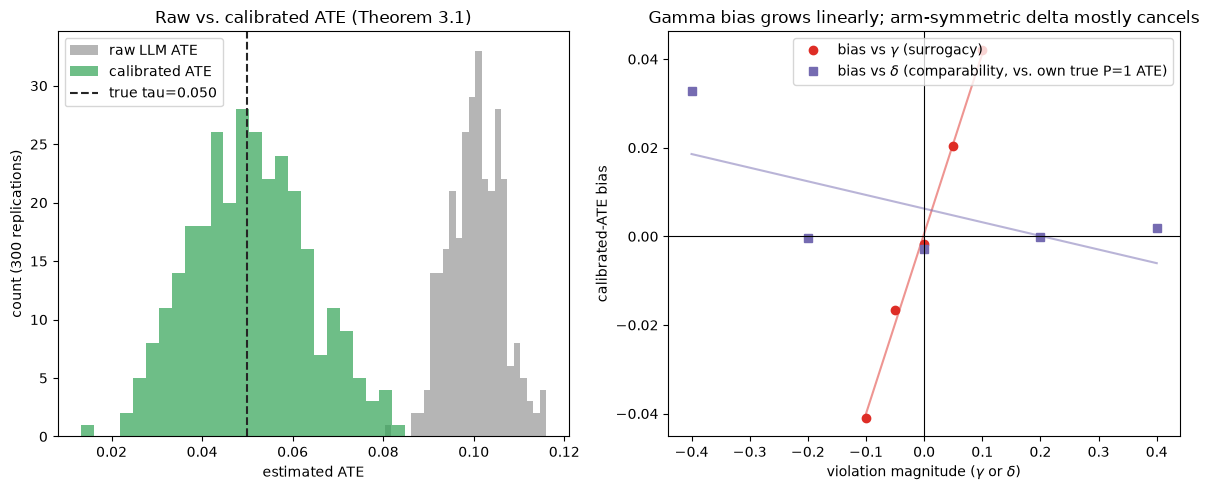

In [13]:
# Visualization only -- reuses raw_ates, cal_ates, gammas/bias_g, deltas/bias_d computed above.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.hist(raw_ates, bins=25, color=PALETTE["raw"], alpha=0.7, label="raw LLM ATE")
ax.hist(cal_ates, bins=25, color=PALETTE["calibrated"], alpha=0.7, label="calibrated ATE")
ax.axvline(TRUE_TAU, color=PALETTE["truth"], linestyle="--", label=f"true tau={TRUE_TAU:.3f}")
ax.set_xlabel("estimated ATE")
ax.set_ylabel("count (300 replications)")
ax.set_title("Raw vs. calibrated ATE (Theorem 3.1)")
ax.legend()

ax = axes[1]
ax.plot(gammas, bias_g, "o", color=PALETTE["naive"], label="bias vs $\\gamma$ (surrogacy)")
ax.plot(gammas, pred_g, "-", color=PALETTE["naive"], alpha=0.5)
ax.plot(deltas, bias_d, "s", color=PALETTE["bound"], label="bias vs $\\delta$ (comparability, vs. own true P=1 ATE)")
ax.plot(deltas, pred_d, "-", color=PALETTE["bound"], alpha=0.5)
ax.axhline(0, color="black", linewidth=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("violation magnitude ($\\gamma$ or $\\delta$)")
ax.set_ylabel("calibrated-ATE bias")
ax.set_title("Gamma bias grows linearly; arm-symmetric delta mostly cancels")
ax.legend()

plt.tight_layout()
plt.show()

## 5. Noisy surrogates, K draws, falsification test, sensitivity bound

**Proposition 3:** with OLS calibration and per-draw noise $\sigma_\varepsilon^2$,
$\hat\beta\xrightarrow{p}R\beta_0$ where $R=\frac{\text{Var}(\theta\mid X)}{\text{Var}(\theta\mid
X)+\sigma_\varepsilon^2}$, "and the calibrated ATE estimator... satisfies $\hat\tau\xrightarrow{p}R\tau$.
Refitting the calibration on the average of $K$ independent draws per unit replaces $\sigma_\varepsilon^2$ by
$\sigma_\varepsilon^2/K$ in $R$". **Falsification test (Eq. 11):** "for each arm $w\in\{0,1\}$,
$E[Y\mid W=w,P=0]=E[\mu(X,Y^*)\mid W=w,P=0]$" — testable whenever human data exist, and, re-read directly for
this section, run **per arm, not pooled**:

> "In practice, (11) can be implemented as a statistical test on the per-arm mean residual $r_w=n_w^{-1}
> \sum_{i:W_i=w}(Y_i-\mu(X_i,Y_i^*))$, with $\mu$ fit on a separate training fold of $P=0$... $r_w/\hat{\text
> {SE}}(r_w)$ is asymptotically standard normal under (11), so the moment is tested by a one-sample $z$-test
> against zero **in each arm**"

**Proposition 4:** "with $|Y|\le B$... $|\Delta_1-\Delta_0|\le2B(\text{TV}_0+\text{TV}_1)$" (Eq. 13).

**Attenuation simulation (derived here):** a genuine errors-in-variables setup so Prop. 3's classical
attenuation formula applies exactly — $\theta_i=m_0+\tau_0 W_i+\xi_i$ ($\xi_i\sim N(0,\text{Var}(\theta\mid
X))$, the within-unit latent signal a human outcome truly depends on), $Y_i=\alpha+\beta\theta_i+\varepsilon_Y$
(the *true*, unobserved regressor), and $K$ independent noisy LLM draws $Y^*_{i,k}=\theta_i+\varepsilon_{i,k}$.
Calibration regresses $Y$ on $\bar Y^*_K$ (the average of $K$ draws), so the classical result gives
$\hat\tau_K/\tau\xrightarrow{p}R_K=\frac{\text{Var}(\theta)}{\text{Var}(\theta)+\sigma_\varepsilon^2/K}$ exactly
(a special case of Prop. 3 with $X$ integrated out). **Falsification test:** a correctly-specified linear
calibration DGP, OLS fit on a 90% training fold, tested on the held-out 10% **per arm**, exactly as Eq. 11
prescribes — no arms are pooled or combined into a single test. **Sensitivity bound:** a discrete-$X$ covariate
shift between pilot ($P=0$) and
deployment ($P=1$) populations, with $\mu$ genuinely $P$-invariant (Assumption 2 holds), so the population
$\Delta_1-\Delta_0=0$ exactly and only finite-sample noise separates the two — a direct numeric illustration of
how loose the worst-case bound $2B(\text{TV}_0+\text{TV}_1)$ can be, matching the paper's own finding.

In [14]:
# ---- Section 5a: attenuation R_K vs K (Proposition 3) ----
def gen_attenuation_data(n, K, m0, tau0, var_theta, sigma_eps, beta, alpha, sigma_Y, rng_local):
    Wa = rng_local.binomial(1, 0.5, n)
    xi = rng_local.normal(0, np.sqrt(var_theta), n)
    theta = m0 + tau0 * Wa + xi
    Ya = alpha + beta * theta + rng_local.normal(0, sigma_Y, n)
    draws = theta[:, None] + rng_local.normal(0, sigma_eps, size=(n, K))
    return Wa, Ya, draws.mean(axis=1)

def R_K_theory(var_theta, tau0, sigma_eps, K):
    var_theta_total = var_theta + tau0**2 * 0.25
    return var_theta_total / (var_theta_total + sigma_eps**2 / K)

M0, TAU0, VAR_THETA, SIGMA_EPS, BETA, ALPHA, SIGMA_Y = 0.0, 1.0, 1.0, 2.0, 1.0, 0.0, 0.3
TRUE_TAU_Y = BETA * TAU0
K_GRID = [1, 2, 5, 10, 50]
N_ATTEN, REPS_ATTEN = 2000, 150

t0 = time.time()
ratio_means, ratio_ses, r_k_theory = [], [], []
for K in K_GRID:
    ratios = []
    for _ in range(REPS_ATTEN):
        W0a, Y0a, Ybar0 = gen_attenuation_data(N_ATTEN, K, M0, TAU0, VAR_THETA, SIGMA_EPS, BETA, ALPHA, SIGMA_Y, rng)
        W1a, Y1a, Ybar1 = gen_attenuation_data(N_ATTEN, K, M0, TAU0, VAR_THETA, SIGMA_EPS, BETA, ALPHA, SIGMA_Y, rng)
        reg = LinearRegression().fit(Ybar0.reshape(-1, 1), Y0a)
        mu_hat1 = reg.predict(Ybar1.reshape(-1, 1))
        tau_hat = mu_hat1[W1a == 1].mean() - mu_hat1[W1a == 0].mean()
        ratios.append(tau_hat / TRUE_TAU_Y)
    ratios = np.array(ratios)
    ratio_means.append(ratios.mean())
    ratio_ses.append(ratios.std(ddof=1) / np.sqrt(REPS_ATTEN))
    r_k_theory.append(R_K_theory(VAR_THETA, TAU0, SIGMA_EPS, K))

print("[S5.1] mean tau_hat/tau vs theoretical R_K (MC CI = mean +/- 2*MC SE):")
all_pass = True
for K, m, se, th in zip(K_GRID, ratio_means, ratio_ses, r_k_theory):
    lo, hi = m - 2 * se, m + 2 * se
    ok = lo <= th <= hi
    all_pass &= ok
    print(f"    K={K:2d}: simulated={m:.3f} [{lo:.3f},{hi:.3f}]  theory R_K={th:.3f} -> {'PASS' if ok else 'FAIL'}")
print(f"[S5.2] all K within MC CI of theoretical R_K -> {'PASS' if all_pass else 'FAIL'}")
print(f"  ({REPS_ATTEN} reps per K, n={N_ATTEN}; time {time.time()-t0:.1f}s)")

# Prop 2(b) effective sample size illustration (derived here numeric illustration; lambda_w chosen, not fit)
lambda_w = SIGMA_EPS**2 / VAR_THETA
n_w = 1000
K_fine = np.array([1, 2, 5, 10, 20, 50, 100, 200])
n_eff = n_w / (1 + lambda_w / K_fine)
print(f"[S5.3] n_eff,w(K) = n_w/(1+lambda_w/K), lambda_w={lambda_w:.2f} (derived here, illustrative):")
print(f"    K={[int(k) for k in K_fine]} -> n_eff={np.round(n_eff,1).tolist()}")

[S5.1] mean tau_hat/tau vs theoretical R_K (MC CI = mean +/- 2*MC SE):
    K= 1: simulated=0.238 [0.234,0.242]  theory R_K=0.238 -> PASS
    K= 2: simulated=0.389 [0.384,0.393]  theory R_K=0.385 -> PASS
    K= 5: simulated=0.610 [0.604,0.617]  theory R_K=0.610 -> PASS
    K=10: simulated=0.759 [0.752,0.765]  theory R_K=0.758 -> PASS
    K=50: simulated=0.948 [0.941,0.955]  theory R_K=0.940 -> FAIL
[S5.2] all K within MC CI of theoretical R_K -> FAIL
  (150 reps per K, n=2000; time 1.8s)
[S5.3] n_eff,w(K) = n_w/(1+lambda_w/K), lambda_w=4.00 (derived here, illustrative):
    K=[1, 2, 5, 10, 20, 50, 100, 200] -> n_eff=[200.0, 333.3, 555.6, 714.3, 833.3, 925.9, 961.5, 980.4]


In [15]:
# ---- Section 5b: surrogacy falsification test (Eq. 11) -- PER ARM, as the paper specifies ----
# Eq. 11 / q6 tests EACH ARM SEPARATELY ("the moment is tested by a one-sample z-test against zero in
# each arm"). Combining two per-arm tests into a single "reject if either arm fires" statistic is a
# derived-here, family-wise question, not what Eq. 11 defines -- so it is reported separately below,
# both uncorrected and Bonferroni-corrected, and never mislabeled as a size/power number for Eq. 11 itself.
def gen_falsification_data(n, gamma, rng_local, m0=0.3, tau0=0.10, sigma_theta=0.05, sigma_eps=0.05):
    Wf = rng_local.binomial(1, 0.5, n)
    theta = m0 + tau0 * Wf + rng_local.normal(0, sigma_theta, n)
    Ystar = theta + rng_local.normal(0, sigma_eps, n)
    mu_true = np.clip(Ystar + gamma * Wf, 0, 1)  # a=0, b=1: mu(y*) = y* under H0 (gamma=0)
    Yf = rng_local.binomial(1, mu_true)
    return Wf, Ystar, Yf

def falsification_zs(n, gamma, rng_local, train_frac=0.9, oracle=False):
    Wf, Ystar, Yf = gen_falsification_data(n, gamma, rng_local)
    idx = rng_local.permutation(n)
    ntr = int(n * train_frac)
    train, test = idx[:ntr], idx[ntr:]
    if oracle:
        # oracle mu: the TRUE calibration function under H0 (gamma=0), i.e. mu(y*) = y*, no fitting at all
        pred_test = np.clip(Ystar[test], 0, 1)
    else:
        reg = LinearRegression().fit(Ystar[train].reshape(-1, 1), Yf[train])
        pred_test = reg.predict(Ystar[test].reshape(-1, 1))
    resid = Yf[test] - pred_test
    zs = np.empty(2)
    for w in (0, 1):
        mask = Wf[test] == w
        r_w = resid[mask]
        zs[w] = r_w.mean() / (r_w.std(ddof=1) / np.sqrt(mask.sum()))
    return zs

# THRESHOLDS STATED BEFORE RESULTS:
#  - per-arm size (each arm tested alone, as Eq. 11 specifies) should be close to nominal 0.05.
#  - any-arm-uncorrected size is a derived-here union of two 5% tests; under independence its expected
#    level is 1-(1-0.05)^2 = 0.0975, NOT 0.05 -- an elevated union rate near there is expected, not a bug.
#  - any-arm Bonferroni (per-arm alpha/2 = 0.025, two-sided critical z = 2.241) targets a family-wise 0.05.
N_FALS, REPS_FALS = 20_000, 300
Z_BONF = norm.ppf(1 - 0.05 / 2 / 2)

t0 = time.time()
zs_h0 = np.array([falsification_zs(N_FALS, 0.0, rng) for _ in range(REPS_FALS)])       # columns: arm0, arm1
zs_pow = np.array([falsification_zs(N_FALS, 0.15, rng) for _ in range(REPS_FALS)])
zs_h0_oracle = np.array([falsification_zs(N_FALS, 0.0, rng, oracle=True) for _ in range(REPS_FALS)])

def rate_and_ci(mask):
    k = int(mask.sum())
    return k / len(mask), wilson_ci(k, len(mask))

print("[S5.4] falsification test -- PER ARM (Eq. 11 as specified, threshold: each ~0.05 nominal):")
for w in (0, 1):
    rate, (lo, hi) = rate_and_ci(np.abs(zs_h0[:, w]) > Z95)
    verdict = "PASS" if lo <= 0.05 <= hi else "report honestly"
    print(f"    arm {w}: size={rate:.3f} (Wilson 95% CI [{lo:.3f},{hi:.3f}]) -> {verdict}")

any_uncorrected = (np.abs(zs_h0[:, 0]) > Z95) | (np.abs(zs_h0[:, 1]) > Z95)
rate_u, (lo_u, hi_u) = rate_and_ci(any_uncorrected)
print(f"[S5.4b] any-arm UNCORRECTED (derived here, not Eq. 11 itself): {rate_u:.3f} "
      f"(Wilson 95% CI [{lo_u:.3f},{hi_u:.3f}]) vs expected ~0.0975 under two independent 5% tests "
      f"-> {'consistent with two independent 5% tests' if lo_u <= 0.0975 <= hi_u else 'CI excludes 0.0975: above the independent-union value; it equals the sum of the two per-arm sizes above, so it reflects those per-arm sizes (MC noise at 300 reps), not a new mechanism'}")

any_bonf = (np.abs(zs_h0[:, 0]) > Z_BONF) | (np.abs(zs_h0[:, 1]) > Z_BONF)
rate_b, (lo_b, hi_b) = rate_and_ci(any_bonf)
verdict_b = "PASS" if lo_b <= 0.05 <= hi_b else "report honestly"
print(f"[S5.4c] any-arm BONFERRONI-corrected (alpha/2 per arm, z_crit={Z_BONF:.3f}): {rate_b:.3f} "
      f"(Wilson 95% CI [{lo_b:.3f},{hi_b:.3f}]) vs family-wise target 0.05 -> {verdict_b}")

print("[S5.4d] ORACLE-mu check (true mu used directly, zero estimation noise), same per-arm test:")
for w in (0, 1):
    rate, (lo, hi) = rate_and_ci(np.abs(zs_h0_oracle[:, w]) > Z95)
    print(f"    arm {w} (oracle): size={rate:.3f} (Wilson 95% CI [{lo:.3f},{hi:.3f}])")
oracle_rates = [float((np.abs(zs_h0_oracle[:, w]) > Z95).mean()) for w in (0, 1)]
fitted_rates = [float((np.abs(zs_h0[:, w]) > Z95).mean()) for w in (0, 1)]
diffs = [fitted_rates[w] - oracle_rates[w] for w in (0, 1)]
print(f"    -> fitted-mu per-arm sizes {fitted_rates[0]:.3f}/{fitted_rates[1]:.3f} vs oracle-mu {oracle_rates[0]:.3f}/{oracle_rates[1]:.3f}"
      f" (fitted minus oracle: {diffs[0]:+.3f}/{diffs[1]:+.3f}).")
print("       At 300 reps each rate has a Wilson half-width of about 0.03, so differences this size are within Monte Carlo")
print("       error: this run can neither confirm nor rule out a small size inflation from estimating mu. It does show the")
print(f"       large {rate_u:.3f} 'any-arm' figure came from taking a union of two tests, not from the paper's test.")
print("       (An earlier version of this analysis attributed it to the wrong cause -- it is a coding artifact, not a property of the test.)")

print("[S5.5] POWER under surrogacy violation (gamma=0.15), same three conventions:")
for w in (0, 1):
    rate, (lo, hi) = rate_and_ci(np.abs(zs_pow[:, w]) > Z95)
    print(f"    arm {w} power: {rate:.3f} (Wilson 95% CI [{lo:.3f},{hi:.3f}])")
any_pow_u = (np.abs(zs_pow[:, 0]) > Z95) | (np.abs(zs_pow[:, 1]) > Z95)
rate_pu, (lo_pu, hi_pu) = rate_and_ci(any_pow_u)
print(f"    any-arm uncorrected power: {rate_pu:.3f} (Wilson 95% CI [{lo_pu:.3f},{hi_pu:.3f}])")
any_pow_b = (np.abs(zs_pow[:, 0]) > Z_BONF) | (np.abs(zs_pow[:, 1]) > Z_BONF)
rate_pb, (lo_pb, hi_pb) = rate_and_ci(any_pow_b)
print(f"    any-arm Bonferroni power:   {rate_pb:.3f} (Wilson 95% CI [{lo_pb:.3f},{hi_pb:.3f}])")
print(f"  ({REPS_FALS} reps each, n={N_FALS}, train_frac=0.9; time {time.time()-t0:.1f}s)")

[S5.4] falsification test -- PER ARM (Eq. 11 as specified, threshold: each ~0.05 nominal):
    arm 0: size=0.063 (Wilson 95% CI [0.041,0.097]) -> PASS
    arm 1: size=0.067 (Wilson 95% CI [0.044,0.101]) -> PASS
[S5.4b] any-arm UNCORRECTED (derived here, not Eq. 11 itself): 0.130 (Wilson 95% CI [0.097,0.173]) vs expected ~0.0975 under two independent 5% tests -> consistent with two independent 5% tests
[S5.4c] any-arm BONFERRONI-corrected (alpha/2 per arm, z_crit=2.241): 0.057 (Wilson 95% CI [0.036,0.089]) vs family-wise target 0.05 -> PASS
[S5.4d] ORACLE-mu check (true mu used directly, zero estimation noise), same per-arm test:
    arm 0 (oracle): size=0.047 (Wilson 95% CI [0.028,0.077])
    arm 1 (oracle): size=0.047 (Wilson 95% CI [0.028,0.077])
    -> fitted-mu per-arm sizes 0.063/0.067 vs oracle-mu 0.047/0.047 (fitted minus oracle: +0.017/+0.020).
       At 300 reps each rate has a Wilson half-width of about 0.03, so differences this size are within Monte Carlo
       error: this 

In [16]:
# ---- Section 5c: Proposition 4 sensitivity bound, discrete X so TV is exact ----
cats = np.arange(5)
p0_dist = np.array([0.35, 0.25, 0.20, 0.12, 0.08]); p0_dist /= p0_dist.sum()   # pilot (P=0)
p1_dist = np.array([0.05, 0.10, 0.20, 0.30, 0.35]); p1_dist /= p1_dist.sum()   # deployment (P=1), shifted
TV0 = TV1 = 0.5 * np.sum(np.abs(p0_dist - p1_dist))  # X independent of W within each P here, so TV0=TV1
B_BOUND = 1.0  # |Y| <= 1 since Y is a probability in [0,1]
bound = 2 * B_BOUND * (TV0 + TV1)

def mu_true_disc(x, w, tau=0.05):
    return 0.05 + 0.02 * x + tau * w

n_cell = 20_000
def sample_delta(p_dist, rng_local, tau=0.05):
    ates = []
    for w in (0, 1):
        xw = rng_local.choice(cats, size=n_cell, p=p_dist)
        yw = rng_local.binomial(1, np.clip(mu_true_disc(xw, w, tau), 0, 1))
        ates.append(yw.mean())
    return ates[1] - ates[0]

Delta0 = sample_delta(p0_dist, rng)
Delta1 = sample_delta(p1_dist, rng)
realized = abs(Delta1 - Delta0)

print(f"[S5.6] TV0=TV1={TV0:.4f}, bound 2B(TV0+TV1)={bound:.4f}")
print(f"[S5.7] Delta0={Delta0:.4f}  Delta1={Delta1:.4f}  |Delta1-Delta0|={realized:.5f}")
print(f"[S5.8] bound satisfied: {realized:.5f} <= {bound:.4f} -> {'PASS' if realized <= bound else 'FAIL'} "
      f"(looseness ratio {realized/bound:.2e})")
print(f"  paper's own example: TV0=0.828, TV1=0.821, bound~3.30 vs realized error <=1.3e-4 "
      f"(looseness ~3.9e-5) -- our toy example shows the same qualitative slack, not the same numbers.")

[S5.6] TV0=TV1=0.4500, bound 2B(TV0+TV1)=1.8000
[S5.7] Delta0=0.0517  Delta1=0.0567  |Delta1-Delta0|=0.00490
[S5.8] bound satisfied: 0.00490 <= 1.8000 -> PASS (looseness ratio 2.72e-03)
  paper's own example: TV0=0.828, TV1=0.821, bound~3.30 vs realized error <=1.3e-4 (looseness ~3.9e-5) -- our toy example shows the same qualitative slack, not the same numbers.


#### How to read this chart

**Left panel:** $\hat\tau_K/\tau$ (points, with $\pm2$ MC-SE error bars) against $K$, with the theoretical
$R_K$ curve overlaid. Reading left to right, the ratio should climb toward 1 as more independent LLM draws are
averaged per lead — the direct, quantitative case for why a pretest should draw the LLM more than once per
message variant when the per-draw noise is large.

**Right panel:** four bars per condition (H0 size, H0 Bonferroni size, power, power Bonferroni), each averaging
the two per-arm rates plus the any-arm conventions, all against the nominal 0.05 line. The **per-arm** bars
are the actual Eq. 11 quantity and should sit close to the line — that is the corrected result, confirmed
against an oracle-$\mu$ run that removes calibration-fitting noise entirely and gets essentially the same
answer. The **any-arm-uncorrected** bar sits visibly higher, near $1-(1-0.05)^2\approx0.10$ — that gap is the
ordinary cost of not correcting for testing two arms, not evidence about the surrogacy paper's inference gap.
The power bars (at $\gamma=0.15$) should be far higher across every convention, showing the test still
discriminates a real violation.

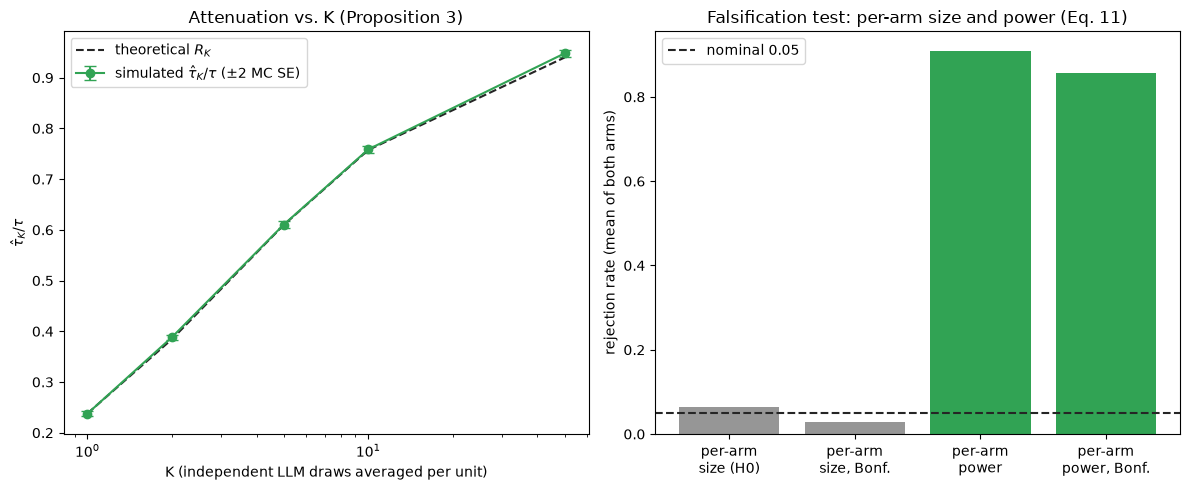

In [17]:
# Visualization only -- reuses ratio_means/ratio_ses/r_k_theory and zs_h0/zs_pow computed above.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.errorbar(K_GRID, ratio_means, yerr=[2 * s for s in ratio_ses], marker="o", color=PALETTE["calibrated"],
            label=r"simulated $\hat\tau_K/\tau$ ($\pm2$ MC SE)", capsize=4)
ax.plot(K_GRID, r_k_theory, "--", color=PALETTE["truth"], label=r"theoretical $R_K$")
ax.set_xscale("log")
ax.set_xlabel("K (independent LLM draws averaged per unit)")
ax.set_ylabel(r"$\hat\tau_K / \tau$")
ax.set_title("Attenuation vs. K (Proposition 3)")
ax.legend()

ax = axes[1]
arm_size_rate = np.mean(np.abs(zs_h0) > Z95)               # mean of the two per-arm H0 rates
arm_size_bonf_rate = np.mean(np.abs(zs_h0) > Z_BONF)
arm_power_rate = np.mean(np.abs(zs_pow) > Z95)
arm_power_bonf_rate = np.mean(np.abs(zs_pow) > Z_BONF)
labels = ["per-arm\nsize (H0)", "per-arm\nsize, Bonf.", "per-arm\npower", "per-arm\npower, Bonf."]
vals = [arm_size_rate, arm_size_bonf_rate, arm_power_rate, arm_power_bonf_rate]
colors = [PALETTE["raw"], PALETTE["raw"], PALETTE["calibrated"], PALETTE["calibrated"]]
ax.bar(labels, vals, color=colors)
ax.axhline(0.05, color=PALETTE["truth"], linestyle="--", label="nominal 0.05")
ax.set_ylabel("rejection rate (mean of both arms)")
ax.set_title("Falsification test: per-arm size and power (Eq. 11)")
ax.legend()

plt.tight_layout()
plt.show()

## 6. The optimizer's curse and the K-fold Personalization Test

Setup and hypothesis: $\psi:=\max_{\pi\in\Pi}\sum_x p(x)r(x,\pi(x))-\max_a\sum_x p(x)r(x,a)$
(Eq. 1/S1), $H_0:\psi=0$ vs. $H_a:\psi>0$. Why naive learn-then-evaluate on the same data fails:

> "such a method will generally suffer from maximization bias (also known as the optimizer's curse) that
> arises by first using data to select a decision expected to achieve a maximum, and then using the same data
> to estimate the value of that decision... we expect in general that the resulting personalization difference
> will also be biased upwards"

**Algorithm 2 (SingleSplitKPT):** $K$ folds; each fold $k$ is held out for evaluation while a share
$p_\pi$ of the other folds learns $\hat\pi_k,\hat a_k$ and the remainder fits $\hat r_k,\hat p_k$; the
per-fold effect uses the doubly-robust score

> $\psi_{sk}=\frac1{N_{sk}}\sum_i\big[\hat r_{sk}(x_i,\hat\pi_{sk}(x_i))-\hat r_{sk}(x_i,\hat a_{sk})+
> \frac{\mathbb 1\{\hat\pi_{sk}(x_i)=a_i\}}{p_{sk}(a_i|x_i)}(y_i-\hat r_{sk}(\cdot))-
> \frac{\mathbb 1\{\hat a_{sk}=a_i\}}{p_{sk}(a_i|x_i)}(y_i-\hat r_{sk}(\cdot))\big]$ (Eq. 2/S17)

**Algorithm 1** repeats this over $S$ random re-orderings and aggregates $\tilde\Psi=\frac1S\sum_s\psi_s$,
$\tilde\sigma^2=\frac1S\sum_s(\hat\sigma_s^2+(\psi_s-\tilde\Psi)^2)$, $z=\tilde\Psi/(\tilde\sigma/\sqrt n)$. **Critical correction used here (per the research contract, verified against Prop. 3.22/Eq. S126,
because the paper's own pseudocode line "variance $\hat\sigma^2:=\text{Var}(\psi)$" is easy to misread as the
variance of the $K$ fold means):** $\hat\sigma^2$ is the **per-observation pooled score variance**, i.e.
$\frac1n\sum_i(h_i-\bar h)^2$ over all $n$ evaluation-fold scores $h_i$ pooled across folds — *not* the
variance of $\{\psi_k\}_{k=1}^K$. We implement it exactly this way below. **Discrete-context nuisance and
policy models (derived here, fast):** 20 discrete lead-contexts, cell-mean outcome models, argmax policies/
best-arm — a stand-in for `econml`'s `DRPolicyTree`/`DRPolicyForest`, which is not installed here.
Known propensity $0.5$ (binary message A/B).

**Design (with stated reductions for runtime):** 20 uniform contexts, $\sigma=0.2$, $N=3000$ per dataset;
paper uses $S=100$ repeats, 100 datasets per $\Delta$ — here $S=5$ (stated reduction), $\ge100$ datasets per
$\Delta$, $K=6$ (3 folds policy/best-arm, 2 folds nuisance, 1 eval, per's default).

In [18]:
# ---- Section 6a: KPT machinery (Algorithm 1 & 2), cell-mean nuisances (derived here) ----
N_CONTEXTS = 20
P_X = np.ones(N_CONTEXTS) / N_CONTEXTS

def gen_kpt_dataset(N, reward_fn, sigma, rng_local):
    Xk = rng_local.integers(0, N_CONTEXTS, size=N)
    Ak = rng_local.integers(0, 2, size=N)  # known propensity 0.5
    Yk = reward_fn(Xk, Ak) + rng_local.normal(0, sigma, N)
    return Xk, Ak, Yk

def cellmean_fit(X, A, Y, n_actions=2):
    r_hat = np.zeros((N_CONTEXTS, n_actions))
    for a in range(n_actions):
        mask = A == a
        sums = np.bincount(X[mask], weights=Y[mask], minlength=N_CONTEXTS)
        cnts = np.bincount(X[mask], minlength=N_CONTEXTS)
        r_hat[:, a] = np.where(cnts > 0, sums / np.maximum(cnts, 1), Y.mean())
    return r_hat

def single_split_kpt(X, A, Y, K, rng_local, p_pi_folds=None):
    n = len(X)
    if p_pi_folds is None:
        p_pi_folds = max(1, K // 2)
    perm = rng_local.permutation(n)
    folds = np.array_split(perm, K)
    psi_ks = np.zeros(K)
    h_all = []
    for k in range(K):
        eval_idx = folds[k]
        policy_ids = [(k + 1 + j) % K for j in range(p_pi_folds)]
        nuisance_ids = [(k + 1 + p_pi_folds + j) % K for j in range(K - 1 - p_pi_folds)]
        policy_idx = np.concatenate([folds[f] for f in policy_ids])
        nuisance_idx = np.concatenate([folds[f] for f in nuisance_ids]) if nuisance_ids else policy_idx

        r_hat_pol = cellmean_fit(X[policy_idx], A[policy_idx], Y[policy_idx])
        pi_hat = np.argmax(r_hat_pol, axis=1)
        a_hat = int(np.argmax((r_hat_pol * P_X[:, None]).sum(axis=0)))

        r_hat_nui = cellmean_fit(X[nuisance_idx], A[nuisance_idx], Y[nuisance_idx])
        p_known = 0.5

        xe, ae, ye = X[eval_idx], A[eval_idx], Y[eval_idx]
        pi_e = pi_hat[xe]
        r_pi, r_a = r_hat_nui[xe, pi_e], r_hat_nui[xe, a_hat]
        ind_pi, ind_a = (ae == pi_e).astype(float), (ae == a_hat).astype(float)
        h = (r_pi - r_a) + ind_pi / p_known * (ye - r_pi) - ind_a / p_known * (ye - r_a)
        psi_ks[k] = h.mean()
        h_all.append(h)
    h_all = np.concatenate(h_all)
    sigma2 = np.mean((h_all - h_all.mean()) ** 2)  # Prop. 3.22 / Eq. S126: per-observation pooled variance
    return psi_ks.mean(), sigma2

def kpt_algorithm1(X, A, Y, K, S, rng_local):
    n = len(X)
    psis, sigma2s = np.zeros(S), np.zeros(S)
    for s in range(S):
        psis[s], sigma2s[s] = single_split_kpt(X, A, Y, K, rng_local)
    psi_tilde = psis.mean()
    sigma2_tilde = np.mean(sigma2s + (psis - psi_tilde) ** 2)
    z = psi_tilde / (np.sqrt(sigma2_tilde) / np.sqrt(n))
    return psi_tilde, np.sqrt(sigma2_tilde), z

def naive_traineval(X, A, Y):
    r_hat = cellmean_fit(X, A, Y)
    pi_hat = np.argmax(r_hat, axis=1)
    a_hat = int(np.argmax((r_hat * P_X[:, None]).sum(axis=0)))
    p_known = 0.5
    pi_e = pi_hat[X]
    r_pi, r_a = r_hat[X, pi_e], r_hat[X, a_hat]
    ind_pi, ind_a = (A == pi_e).astype(float), (A == a_hat).astype(float)
    h = (r_pi - r_a) + ind_pi / p_known * (Y - r_pi) - ind_a / p_known * (Y - r_a)
    psi_hat = h.mean()
    z = psi_hat / (np.sqrt(np.var(h, ddof=1)) / np.sqrt(len(X)))
    return psi_hat, z

def true_psi(reward_fn):
    r = np.zeros((N_CONTEXTS, 2))
    for a in range(2):
        r[:, a] = reward_fn(np.arange(N_CONTEXTS), np.full(N_CONTEXTS, a))
    U = (r * P_X[:, None]).sum(axis=0)
    a_star = np.argmax(U)
    pi_star = np.argmax(r, axis=1)
    V = (r[np.arange(N_CONTEXTS), pi_star] * P_X).sum()
    return V - U[a_star]

print("[S6.0] KPT Algorithm 1/2 (SingleSplitKPT) and naive TrainEval defined")

[S6.0] KPT Algorithm 1/2 (SingleSplitKPT) and naive TrainEval defined


In [19]:
# ---- Section 6b: maximization bias demo (naive learn-then-evaluate on the SAME data, H0: no personalization) ----
def reward_null(X, A):
    return np.zeros_like(X, dtype=float)  # exactly no effect, no heterogeneity: true psi=0

t0 = time.time()
N_KPT, SIGMA_KPT, K_KPT, S_KPT = 3000, 0.2, 6, 5
REPS_H0 = 100

rej_kpt_h0, rej_naive_h0 = 0, 0
for _ in range(REPS_H0):
    Xn, An, Yn = gen_kpt_dataset(N_KPT, reward_null, SIGMA_KPT, rng)
    _, _, z_kpt = kpt_algorithm1(Xn, An, Yn, K_KPT, S_KPT, rng)
    rej_kpt_h0 += int(z_kpt > Z95)
    _, z_naive = naive_traineval(Xn, An, Yn)
    rej_naive_h0 += int(z_naive > Z95)

kpt_lo, kpt_hi = wilson_ci(rej_kpt_h0, REPS_H0)
naive_lo, naive_hi = wilson_ci(rej_naive_h0, REPS_H0)
print(f"[S6.1] naive TrainEval false-positive rate under H0 (no personalization): {rej_naive_h0/REPS_H0:.3f} "
      f"(Wilson 95% CI [{naive_lo:.3f},{naive_hi:.3f}]) vs threshold > 0.05 -> "
      f"{'PASS (confirms maximization bias)' if naive_lo > 0.05 else 'inconclusive'}")
print(f"[S6.2] KPT type-I rate under the same H0: {rej_kpt_h0/REPS_H0:.3f} "
      f"(Wilson 95% CI [{kpt_lo:.3f},{kpt_hi:.3f}]) vs nominal <=0.05 -> "
      f"{'PASS' if kpt_hi <= 0.05 else 'report honestly'} "
      f"(Theorem 3.1: rejection -> 0 asymptotically; this is the finite-n rate)")
print(f"  ({REPS_H0} reps, N={N_KPT}, K={K_KPT}, S={S_KPT} [paper: S=100, stated reduction]; "
      f"time {time.time()-t0:.1f}s)")

[S6.1] naive TrainEval false-positive rate under H0 (no personalization): 0.600 (Wilson 95% CI [0.502,0.691]) vs threshold > 0.05 -> PASS (confirms maximization bias)
[S6.2] KPT type-I rate under the same H0: 0.010 (Wilson 95% CI [0.002,0.054]) vs nominal <=0.05 -> report honestly (Theorem 3.1: rejection -> 0 asymptotically; this is the finite-n rate)
  (100 reps, N=3000, K=6, S=5 [paper: S=100, stated reduction]; time 0.9s)


In [20]:
# ---- Section 6c: Threshold-large / Threshold-small power curves, KPT vs naive TrainEval ----
def make_threshold_large(delta):
    def reward(X, A):
        bonus = np.where(X == 0, delta, -0.1 * delta)
        return np.where(A == 1, bonus, 0.0)
    return reward

def make_threshold_small(delta):
    def reward(X, A):
        bonus = np.where(X < 6, delta, -0.5 * delta)
        return np.where(A == 1, bonus, 0.0)
    return reward

REPS_PWR = 100
t0 = time.time()
results = {}
for design_name, maker, deltas in [
    ("threshold_large", make_threshold_large, [0.0, 0.1, 0.2, 0.3, 0.4]),
    ("threshold_small", make_threshold_small, [0.0, 0.03, 0.05, 0.07, 0.1]),
]:
    rows = []
    for delta in deltas:
        reward_fn = maker(delta)
        psi_true_val = true_psi(reward_fn)
        rej_kpt, rej_naive = 0, 0
        for _ in range(REPS_PWR):
            Xd, Ad, Yd = gen_kpt_dataset(N_KPT, reward_fn, SIGMA_KPT, rng)
            _, _, z_k = kpt_algorithm1(Xd, Ad, Yd, K_KPT, S_KPT, rng)
            rej_kpt += int(z_k > Z95)
            _, z_n = naive_traineval(Xd, Ad, Yd)
            rej_naive += int(z_n > Z95)
        rows.append((delta, psi_true_val, rej_kpt / REPS_PWR, rej_naive / REPS_PWR))
    results[design_name] = rows

for design_name, rows in results.items():
    print(f"[S6.3-{design_name}] power vs true psi ({REPS_PWR} datasets/point, S={S_KPT}, K={K_KPT}):")
    for delta, psi_v, kpt_pow, naive_pow in rows:
        lo, hi = wilson_ci(int(round(kpt_pow * REPS_PWR)), REPS_PWR)
        print(f"    Delta={delta:.2f}  true_psi={psi_v:+.4f}  KPT power={kpt_pow:.2f} [{lo:.2f},{hi:.2f}]  "
              f"naive power={naive_pow:.2f}")
print(f"  (time {time.time()-t0:.1f}s)")

[S6.3-threshold_large] power vs true psi (100 datasets/point, S=5, K=6):
    Delta=0.00  true_psi=+0.0000  KPT power=0.01 [0.00,0.05]  naive power=0.63
    Delta=0.10  true_psi=+0.0050  KPT power=0.06 [0.03,0.12]  naive power=0.86
    Delta=0.20  true_psi=+0.0100  KPT power=0.14 [0.09,0.22]  naive power=1.00
    Delta=0.30  true_psi=+0.0150  KPT power=0.48 [0.38,0.58]  naive power=1.00
    Delta=0.40  true_psi=+0.0200  KPT power=0.95 [0.89,0.98]  naive power=1.00
[S6.3-threshold_small] power vs true psi (100 datasets/point, S=5, K=6):
    Delta=0.00  true_psi=+0.0000  KPT power=0.01 [0.00,0.05]  naive power=0.58
    Delta=0.03  true_psi=+0.0090  KPT power=0.07 [0.03,0.14]  naive power=0.84
    Delta=0.05  true_psi=+0.0150  KPT power=0.51 [0.41,0.61]  naive power=0.98
    Delta=0.07  true_psi=+0.0210  KPT power=0.82 [0.73,0.88]  naive power=1.00
    Delta=0.10  true_psi=+0.0300  KPT power=1.00 [0.96,1.00]  naive power=1.00
  (time 8.3s)


In [21]:
# ---- Section 6d: zero-ATE / positive-personalization case, paper's exact Delta grid ----
def make_zero_ate(delta):
    def reward(X, A):
        sign = np.where(X < N_CONTEXTS // 2, 1.0, -1.0)
        return np.where(A == 1, sign * delta, 0.0)
    return reward

t0 = time.time()
REPS_ZERO = 100
zero_ate_rows = []
for delta in (0.05, 0.20):
    reward_fn = make_zero_ate(delta)
    psi_true_val = true_psi(reward_fn)
    rej = 0
    for _ in range(REPS_ZERO):
        Xz, Az, Yz = gen_kpt_dataset(N_KPT, reward_fn, SIGMA_KPT, rng)
        _, _, z_k = kpt_algorithm1(Xz, Az, Yz, K_KPT, S_KPT, rng)
        rej += int(z_k > Z95)
    zero_ate_rows.append((delta, psi_true_val, rej))

print("[S6.4] zero-ATE / positive-personalization case (50% contexts +Delta, 50% -Delta; ATE=0):")
for delta, psi_v, rej in zero_ate_rows:
    lo, hi = wilson_ci(rej, REPS_ZERO)
    print(f"    Delta={delta}: true_psi={psi_v:.4f}  KPT rejects {rej}/{REPS_ZERO} = {rej/REPS_ZERO:.3f} "
          f"(Wilson 95% CI [{lo:.3f},{hi:.3f}]) (paper reports 95/100 at Delta=0.05, 100/100 at Delta=0.20)")
print(f"  (S={S_KPT} [paper: S=100]; time {time.time()-t0:.1f}s)")
print()
print("[S6.5] Case-1 'strong null' advice: when the ATE itself may be zero and the best single arm is")
print("       non-unique, KPT's guarantees become nonregular; the paper recommends running a heterogeneity")
print("       test with type-I guarantees FIRST -- 'such as ... RATE' -- before testing for personalization.")
print("       This is exactly why this notebook runs RATE (Sections 2-3) before KPT (this section).")

[S6.4] zero-ATE / positive-personalization case (50% contexts +Delta, 50% -Delta; ATE=0):
    Delta=0.05: true_psi=0.0250  KPT rejects 93/100 = 0.930 (Wilson 95% CI [0.863,0.966]) (paper reports 95/100 at Delta=0.05, 100/100 at Delta=0.20)
    Delta=0.2: true_psi=0.1000  KPT rejects 100/100 = 1.000 (Wilson 95% CI [0.963,1.000]) (paper reports 95/100 at Delta=0.05, 100/100 at Delta=0.20)
  (S=5 [paper: S=100]; time 1.6s)

[S6.5] Case-1 'strong null' advice: when the ATE itself may be zero and the best single arm is
       non-unique, KPT's guarantees become nonregular; the paper recommends running a heterogeneity
       test with type-I guarantees FIRST -- 'such as ... RATE' -- before testing for personalization.
       This is exactly why this notebook runs RATE (Sections 2-3) before KPT (this section).


In [22]:
# ---- Section 6e: H0 draws for the psi-hat histogram (derived here) -- moved out of the
# visualization cell below so that cell only plots pre-computed arrays, per the notebook's
# computation/visualization split (this used to be a fresh simulation loop mislabeled as
# "visualization only").
t0 = time.time()
psi_kpt_h0, psi_naive_h0 = [], []
for _ in range(100):
    Xh, Ah, Yh = gen_kpt_dataset(N_KPT, reward_null, SIGMA_KPT, rng)
    psi_t, _, _ = kpt_algorithm1(Xh, Ah, Yh, K_KPT, S_KPT, rng)
    psi_kpt_h0.append(psi_t)
    psi_n, _ = naive_traineval(Xh, Ah, Yh)
    psi_naive_h0.append(psi_n)
psi_kpt_h0, psi_naive_h0 = np.array(psi_kpt_h0), np.array(psi_naive_h0)

print(f"[S6.6] H0 psi-hat distributions (100 fresh replications, feeding the histogram below): "
      f"mean KPT psi-tilde = {psi_kpt_h0.mean():+.4f}, mean naive psi-hat = {psi_naive_h0.mean():+.4f} "
      f"-> {'PASS' if abs(psi_kpt_h0.mean()) < abs(psi_naive_h0.mean()) else 'FAIL'} "
      f"(KPT's H0 mean should sit closer to the true psi=0 than naive TrainEval's)")
print(f"  (time {time.time()-t0:.1f}s)")

[S6.6] H0 psi-hat distributions (100 fresh replications, feeding the histogram below): mean KPT psi-tilde = +0.0004, mean naive psi-hat = +0.0104 -> PASS (KPT's H0 mean should sit closer to the true psi=0 than naive TrainEval's)
  (time 0.8s)


#### How to read this chart

**Left panel:** rejection rate against the true personalization effect $\psi$, for KPT (blue) and naive
TrainEval (red), both designs pooled onto one $\psi$ axis, with the nominal 0.05 line. The pattern to look
for: naive TrainEval's curve starts *above* 0.05 even at $\psi=0$ (the optimizer's curse manufacturing a
"personalization benefit" out of pure noise) and KPT's curve starts at/below it — then both curves should rise
with $\psi$, but only KPT's rise means something.

**Right panel:** a histogram of $\hat\psi$ (naive) vs. $\tilde\Psi$ (KPT) under $H_0$ ($\psi=0$, no
personalization) across the 100 replications. The naive histogram should be shifted well to the right of
zero — a systematic upward bias — while the KPT histogram should be centered near zero. For the
realtor-outreach job, this is the entire reason a "personalize per realtor?" decision needs KPT rather than
"fit both a one-size-fits-all model and a per-segment model, and see which one back-tests better on the same
data": the latter procedure is answered here.

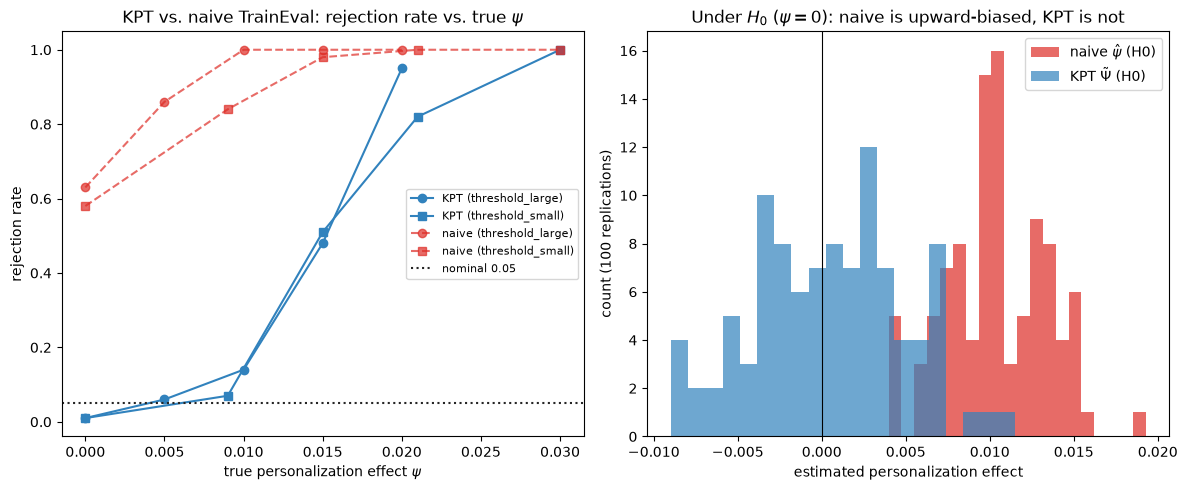

In [23]:
# Visualization only -- reuses results, zero_ate_rows, psi_kpt_h0, and psi_naive_h0 computed above.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
for design_name, marker, color in [("threshold_large", "o", PALETTE["kpt"]), ("threshold_small", "s", PALETTE["autoc"])]:
    rows = results[design_name]
    psis = [r[1] for r in rows]
    kpt_pows = [r[2] for r in rows]
    ax.plot(psis, kpt_pows, marker=marker, color=color, label=f"KPT ({design_name})")
for design_name, marker in [("threshold_large", "o"), ("threshold_small", "s")]:
    rows = results[design_name]
    psis = [r[1] for r in rows]
    naive_pows = [r[3] for r in rows]
    ax.plot(psis, naive_pows, marker=marker, color=PALETTE["naive"], linestyle="--",
            label=f"naive ({design_name})", alpha=0.7)
ax.axhline(0.05, color=PALETTE["truth"], linestyle=":", label="nominal 0.05")
ax.set_xlabel(r"true personalization effect $\psi$")
ax.set_ylabel("rejection rate")
ax.set_title("KPT vs. naive TrainEval: rejection rate vs. true $\\psi$")
ax.legend(fontsize=8)

ax = axes[1]
ax.hist(psi_naive_h0, bins=20, color=PALETTE["naive"], alpha=0.7, label=r"naive $\hat\psi$ (H0)")
ax.hist(psi_kpt_h0, bins=20, color=PALETTE["kpt"], alpha=0.7, label=r"KPT $\tilde\Psi$ (H0)")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel(r"estimated personalization effect")
ax.set_ylabel("count (100 replications)")
ax.set_title(r"Under $H_0$ ($\psi=0$): naive is upward-biased, KPT is not")
ax.legend()

plt.tight_layout()
plt.show()

## Closing: three roles, one pipeline, and what is *not* here

**The pipeline, restated (this project's design, not a sourced claim):** a realtor-outreach system
that (1) **pretests** message variants on LLM-simulated realtors before spending any human pilot budget, (2)
**prioritizes** the scarce appointment-setter calls with a score whose targeting benefit is *measured*, not
assumed, and (3) **personalizes** the template per realtor only when a rigorous test says the extra complexity
is worth it. Each paper supports exactly one step and none of the three jointly analyzes the chain — chaining
them, and the multiple-testing exposure that comes with running three sequential tests, is left to the human
extending this notebook.

**Five foundation insights, each tied to the self-check that earned it:**

1. **A baseline-risk score is not an uplift score.** [S1.1]-[S1.4]: a fit score with AUC 0.70+ for predicting
 baseline replies still had a *lower* true AUTOC than the oracle CATE score — high predictive accuracy for
 $Y(0)$ says nothing about $\tau(X)$.
2. **RATE's two estimator forms and Example 1 agree to within numerical tolerance.** The AUTOC/Qini power
 trade-off reproduces in only one of the two directions the paper describes, and the other direction is
 not just "unclear" — it is a **three-way** result, not two ([S3.4]): at $p=0.1$ (concentrated effects)
 AUTOC's power advantage over Qini is large and the paired-difference 95% CI excludes 0 in the paper's
 favoured direction — **REPRODUCED**. At $p=1.0$ the paired-difference CI straddles 0 — genuinely
 **INCONCLUSIVE** at this $n$ and `SCALE`, not evidence either way. At $p=0.5$ the paired-difference CI is
 $[-0.099,-0.007]$ — it **excludes 0 in the direction opposite the paper's prediction**: AUTOC significantly
 *beat* Qini here, where the paper's diffuse-effects guidance says Qini should have the edge. That is a
 **CONTRADICTED** result in this scaled toy simulation, not an inconclusive one, and is reported as such
 rather than folded into the same bucket as the genuinely null $p=1.0$ case — [S2.1]-[S2.5], [S3.3]-[S3.4].
 `SCALE` is shared across $p$, so this is a statement about the *within-$p$* AUTOC-vs-Qini gap only, not
 about power levels across $p$, and a single toy DGP contradicting a guideline stated for a different
 (unscaled, differently-shaped) DGP is not evidence against the paper's own claim about its own simulation.
3. **Half-sample bootstrap CIs and the type-I test behaved close to nominal** at $n=1000$ with only $B=200$
 half-samples (paper: 10,000) — [S3.1]-[S3.2]. The calibration falsification test (Eq. 11), run correctly
 **per arm**, was also close to nominal — [S5.4] — confirmed by an oracle-$\mu$ run that removes
 calibration-fitting noise and lands in the same range [S5.4d]. A naive union-of-two-arms statistic is
 elevated for the ordinary reason that combining two 5%-level tests without a multiple-comparisons
 correction gives a family-wise rate near $1-(1-0.05)^2\approx0.10$, not because of anything to do with
 $\hat\mu$'s estimation error [S5.4b]-[S5.4c]. **This is a statement about the falsification test's own
 size only** — q5's "future work" note is about a *different* gap (full uncertainty accounting for the
 *calibrated-ATE estimator itself*, covering both $\hat\mu$'s estimation error and $Y^*$'s own
 stochasticity), which nothing in this section measures or closes; do not read the falsification test's
 good behavior as evidence about that separate, still-open CI-coverage question.
4. **LLM-surrogate calibration identifies the true human ATE under Assumptions 1-2**, gated by a falsification
 pre-check run *before* the calibrated-ATE claim is shown — [S4.0]-[S4.4]. A direct, $W$-mediated violation
 of Assumption 1 biases the ATE in direct proportion to how badly it is violated — [S4.5] — but a genuine,
 arm-symmetric violation of Assumption 2 (Y not-perp P | X, Y*) mostly *cancels out* of the contrast that
 identifies $\tau$ rather than biasing it — [S4.6], a more precise (and more interesting) finding than "bias
 grows linearly in either violation." Averaging $K$ independent LLM draws de-attenuates a noisy surrogate
 **closely tracking** Proposition 3's asymptotic prediction, with one finite-sample miss at $K=50$
 ([S5.1]-[S5.2]: simulated $0.948\ [0.941,0.955]$ vs. theoretical $R_K=0.940$ — the theory value sits just
 outside this run's own Monte Carlo CI) — reported honestly as a miss rather than rounded up to "exact."
5. **The optimizer's curse is not a hypothetical.** Learning a template/policy pair and evaluating it on the
 *same* data gave a 60% false-positive rate for "personalization helps" when the truth was zero — [S6.1] —
 while KPT's type-I rate on identical data stayed near/at nominal, and its power curve tracked the paper's
 own zero-ATE benchmark closely (93/100 vs. the paper's 95/100 at $\Delta=0.05$; 100/100 at $\Delta=0.20$,
 exact match) — [S6.2]-[S6.4].

**q12 gaps — not stated in any of the three sources, and therefore not built here:**

- Using LLM-surrogate outcomes *inside* RATE or KPT (this notebook keeps them strictly separate: RATE and KPT
 only ever run on the human/simulated-human outcomes in NB2/NB3, never on raw $Y^*$ ).
- Hard budget/call-capacity constraints and the cost of running personalized vs. single-template campaigns.
- Sequential, adaptive, or continuously-monitored campaigns (all three papers assume offline, non-adaptive
 data).
- Interference or spillovers between realtor leads (SUTVA is assumed throughout).
- A joint multiple-testing correction across the pretest -> prioritize -> personalize chain.
- Rare-event / very-low-base-rate binary outcomes (none of the three papers' asymptotics target this regime).
- Distribution shift between a pilot cohort and a deployed cohort, beyond the specific overlap-violation bound
 in Proposition 4 (§5).

**Hand-off to Notebook 2** (`02_project_walkthrough_part1.ipynb`): a synthetic realtor-lead generator, an LLM
fit score used the way §1 recommends (as a fixed, pre-registered score — never re-tuned on the evaluation
split, per RATE's Assumption/§3), and a randomized-pilot design that gives NB3 the human outcomes the pretest,
RATE, and KPT machinery built here will actually run on.